In [ ]:
# IRC Disentanglement Dataset Exploration
"""
Comprehensive notebook for exploring the IRC Disentanglement Dataset
Dataset: https://www.tensorflow.org/datasets/catalog/irc_disentanglement
Paper: http://jkk.name/irc-disentanglement/

This notebook provides tools to load, analyze, and visualize the IRC dataset
which contains annotated conversations for disentanglement research.
"""

import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

print("IRC Dataset Exploration Notebook")
print("=" * 50)
print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow Datasets version: {tfds.__version__}")

# ============================================================================
# 1. DATASET LOADING AND BASIC INFO
# ============================================================================

def load_irc_dataset(split='train', as_supervised=False):
    """
    Load the IRC disentanglement dataset

    Args:
        split: Dataset split ('train', 'validation', 'test')
        as_supervised: Whether to load as supervised format

    Returns:
        Dataset object
    """
    try:
        dataset = tfds.load('irc_disentanglement',
                          split=split,
                          as_supervised=as_supervised,
                          shuffle_files=False)
        return dataset
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Make sure tensorflow-datasets is installed and the dataset is available")
        return None

def get_dataset_info():
    """Get detailed information about the IRC dataset"""
    try:
        builder = tfds.builder('irc_disentanglement')
        info = builder.info

        print("Dataset Information:")
        print("-" * 30)
        print(f"Description: {info.description}")
        print(f"Version: {info.version}")
        print(f"Total size: {info.download_size}")
        print(f"Features: {info.features}")
        print(f"Splits: {info.splits}")

        return info
    except Exception as e:
        print(f"Error getting dataset info: {e}")
        return None

# Load dataset info
dataset_info = get_dataset_info()


IRC Dataset Exploration Notebook
TensorFlow version: 2.19.0
TensorFlow Datasets version: 4.9.9
Dataset Information:
------------------------------
Description: IRC Disentanglement dataset contains over 77,563 messages from Ubuntu IRC
channel.

Features include message id, message text and timestamp. Target is list of
messages that current message replies to. Each record contains a list of
messages from one day of IRC chat.
Version: 2.0.0
Total size: Unknown size
Features: FeaturesDict({
    'day': Sequence({
        'id': Text(shape=(), dtype=string),
        'parents': Sequence(Text(shape=(), dtype=string)),
        'text': Text(shape=(), dtype=string),
        'timestamp': Text(shape=(), dtype=string),
    }),
})
Splits: {}


In [ ]:

# ============================================================================
# 2. DATA EXPLORATION FUNCTIONS
# ============================================================================

def explore_dataset_structure(dataset, num_examples=5):
    """Explore the structure of the dataset"""
    print(f"\nExploring first {num_examples} examples:")
    print("-" * 40)

    examples = []
    for i, example in enumerate(dataset.take(num_examples)):
        print(f"\nExample {i+1}:")
        for key, value in example.items():
            if isinstance(value, tf.Tensor):
                val = value.numpy()
                if isinstance(val, bytes):
                    val = val.decode('utf-8')
                elif isinstance(val, np.ndarray) and val.dtype.kind in ['U', 'S']:
                    val = [v.decode('utf-8') if isinstance(v, bytes) else v for v in val.flatten()]
                print(f"  {key}: {val}")
            else:
                print(f"  {key}: {value}")
        examples.append(example)

    return examples

def convert_to_dataframe(dataset, max_examples=1000):
    """Convert dataset examples to pandas DataFrame for easier analysis"""
    data = []

    print(f"Converting up to {max_examples} examples to DataFrame...")

    for i, example in enumerate(dataset.take(max_examples)):
        if i % 100 == 0:
            print(f"Processing example {i}")

        row = {}
        for key, value in example.items():
            if isinstance(value, tf.Tensor):
                val = value.numpy()
                if isinstance(val, bytes):
                    val = val.decode('utf-8')
                elif isinstance(val, np.ndarray):
                    if val.dtype.kind in ['U', 'S']:  # String arrays
                        val = [v.decode('utf-8') if isinstance(v, bytes) else str(v) for v in val.flatten()]
                    val = val.tolist() if val.size > 1 else val.item()
                row[key] = val
            else:
                row[key] = value

        data.append(row)

    df = pd.DataFrame(data)
    print(f"Created DataFrame with {len(df)} rows and {len(df.columns)} columns")

In [ ]:

# ============================================================================
# 3. ANALYSIS FUNCTIONS
# ============================================================================

def analyze_conversation_structure(df):
    """Analyze the structure of conversations"""
    print("Conversation Structure Analysis:")
    print("-" * 35)

    # Basic statistics
    if 'messages' in df.columns:
        message_lengths = df['messages'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        print(f"Number of conversations: {len(df)}")
        print(f"Average messages per conversation: {message_lengths.mean():.2f}")
        print(f"Median messages per conversation: {message_lengths.median():.0f}")
        print(f"Max messages in a conversation: {message_lengths.max()}")
        print(f"Min messages in a conversation: {message_lengths.min()}")

        # Plot distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(message_lengths, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Number of Messages')
        plt.ylabel('Frequency')
        plt.title('Distribution of Messages per Conversation')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.boxplot(message_lengths)
        plt.ylabel('Number of Messages')
        plt.title('Messages per Conversation (Box Plot)')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return message_lengths
    else:
        print("No 'messages' column found in the dataset")
        return None

def analyze_user_participation(df):
    """Analyze user participation patterns"""
    print("\nUser Participation Analysis:")
    print("-" * 30)

    if 'users' in df.columns:
        all_users = []
        for users in df['users']:
            if isinstance(users, list):
                all_users.extend(users)

        user_counts = Counter(all_users)
        print(f"Total unique users: {len(user_counts)}")
        print(f"Average users per conversation: {df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0).mean():.2f}")

        # Top users
        print(f"\nTop 10 most active users:")
        for user, count in user_counts.most_common(10):
            print(f"  {user}: {count} conversations")

        # Plot user activity distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        user_activity = list(user_counts.values())
        plt.hist(user_activity, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Number of Conversations')
        plt.ylabel('Number of Users')
        plt.title('User Activity Distribution')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        users_per_conv = df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        plt.hist(users_per_conv, bins=30, alpha=0.7, edgecolor='black')
        plt.xlabel('Users per Conversation')
        plt.ylabel('Frequency')
        plt.title('Distribution of Users per Conversation')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return user_counts
    else:
        print("No 'users' column found in the dataset")
        return None

def analyze_message_content(df):
    """Analyze message content characteristics"""
    print("\nMessage Content Analysis:")
    print("-" * 25)

    if 'messages' in df.columns:
        all_messages = []
        message_lengths = []

        for messages in df['messages']:
            if isinstance(messages, list):
                for msg in messages:
                    if isinstance(msg, str):
                        all_messages.append(msg)
                        message_lengths.append(len(msg.split()))

        print(f"Total messages: {len(all_messages)}")
        print(f"Average words per message: {np.mean(message_lengths):.2f}")
        print(f"Median words per message: {np.median(message_lengths):.0f}")

        # Analyze common words/patterns
        all_text = ' '.join(all_messages[:1000])  # Sample first 1000 messages
        words = re.findall(r'\b\w+\b', all_text.lower())
        word_freq = Counter(words)

        print(f"\nTop 15 most common words:")
        for word, count in word_freq.most_common(15):
            print(f"  {word}: {count}")

        # Plot message length distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(message_lengths, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Words per Message')
        plt.ylabel('Frequency')
        plt.title('Message Length Distribution')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        # Word frequency plot
        top_words = word_freq.most_common(20)
        words, counts = zip(*top_words)
        plt.barh(range(len(words)), counts)
        plt.yticks(range(len(words)), words)
        plt.xlabel('Frequency')
        plt.title('Top 20 Most Common Words')
        plt.gca().invert_yaxis()

        plt.tight_layout()
        plt.show()

        return {'messages': all_messages, 'word_freq': word_freq, 'message_lengths': message_lengths}
    else:
        print("No 'messages' column found in the dataset")
        return None

def analyze_annotations(df):
    """Analyze annotation patterns if available"""
    print("\nAnnotation Analysis:")
    print("-" * 20)

    annotation_columns = [col for col in df.columns if 'annotation' in col.lower() or 'label' in col.lower()]

    if annotation_columns:
        for col in annotation_columns:
            print(f"\nColumn: {col}")
            if df[col].dtype == 'object':
                value_counts = df[col].value_counts()
                print(f"Unique values: {len(value_counts)}")
                print("Value distribution:")
                for value, count in value_counts.head(10).items():
                    print(f"  {value}: {count}")
            else:
                print(f"Numeric column stats:")
                print(f"  Mean: {df[col].mean():.2f}")
                print(f"  Std: {df[col].std():.2f}")
                print(f"  Min: {df[col].min()}")
                print(f"  Max: {df[col].max()}")
    else:
        print("No obvious annotation columns found")
        print(f"Available columns: {list(df.columns)}")

In [ ]:

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_conversations=20):
    """Create a heatmap showing conversation activity patterns"""
    if 'messages' not in df.columns or 'users' not in df.columns:
        print("Required columns not found for heatmap")
        return

    # Prepare data for heatmap
    conv_data = []
    for i, (messages, users) in enumerate(zip(df['messages'][:max_conversations],
                                            df['users'][:max_conversations])):
        if isinstance(messages, list) and isinstance(users, list):
            conv_data.append({
                'conversation': i,
                'messages': len(messages),
                'users': len(users),
                'avg_msg_per_user': len(messages) / len(users) if len(users) > 0 else 0
            })

    if conv_data:
        heatmap_df = pd.DataFrame(conv_data)

        plt.figure(figsize=(12, 8))

        # Create correlation matrix
        corr_data = heatmap_df[['messages', 'users', 'avg_msg_per_user']]
        correlation_matrix = corr_data.corr()

        plt.subplot(2, 2, 1)
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap')

        plt.subplot(2, 2, 2)
        plt.scatter(heatmap_df['users'], heatmap_df['messages'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Number of Messages')
        plt.title('Users vs Messages')

        plt.subplot(2, 2, 3)
        plt.scatter(heatmap_df['users'], heatmap_df['avg_msg_per_user'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Average Messages per User')
        plt.title('Users vs Avg Messages per User')

        plt.subplot(2, 2, 4)
        plt.hist2d(heatmap_df['messages'], heatmap_df['users'], bins=20, cmap='Blues')
        plt.colorbar()
        plt.xlabel('Number of Messages')
        plt.ylabel('Number of Users')
        plt.title('2D Histogram: Messages vs Users')

        plt.tight_layout()
        plt.show()

In [ ]:

# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("Starting IRC Dataset Analysis...")
    print("=" * 50)

    # Load the training dataset
    train_dataset = load_irc_dataset('train')

    if train_dataset is None:
        print("Failed to load dataset. Please check your installation.")
        return

    # Explore structure
    examples = explore_dataset_structure(train_dataset, num_examples=3)

    # Convert to DataFrame for easier analysis
    df = convert_to_dataframe(train_dataset, max_examples=500)

    if df is not None and not df.empty:
        print(f"\nDataFrame shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Run analyses
        message_stats = analyze_conversation_structure(df)
        user_stats = analyze_user_participation(df)
        content_stats = analyze_message_content(df)
        analyze_annotations(df)

        # Create visualizations
        create_conversation_heatmap(df)

        print("\nAnalysis complete!")
        print("=" * 50)

        return df, examples
    else:
        print("Failed to create DataFrame from dataset")
        return None, examples

In [ ]:

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for conversations containing a specific keyword"""
    if 'messages' not in df.columns:
        print("No messages column found")
        return

    matching_convs = []

    for i, messages in enumerate(df['messages']):
        if isinstance(messages, list):
            for msg in messages:
                if isinstance(msg, str) and keyword.lower() in msg.lower():
                    matching_convs.append((i, messages))
                    break

    print(f"Found {len(matching_convs)} conversations containing '{keyword}'")

    for i, (conv_idx, messages) in enumerate(matching_convs[:max_results]):
        print(f"\nConversation {conv_idx}:")
        for j, msg in enumerate(messages[:5]):  # Show first 5 messages
            print(f"  {j+1}: {msg}")
        if len(messages) > 5:
            print(f"  ... and {len(messages)-5} more messages")


In [ ]:

# Run the main analysis
if __name__ == "__main__":
    df, examples = main()

    # Example usage of utility functions
    if df is not None:
        print("\n" + "="*50)
        print("ADDITIONAL ANALYSIS EXAMPLES")
        print("="*50)

        # Export sample
        export_sample_data(df, 'irc_sample.csv', 50)

        # Search for specific content
        search_conversations(df, "help", max_results=3)

        print("\nYou can now use the following variables:")
        print("- df: DataFrame with conversation data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- export_sample_data(df, 'filename.csv')")

Starting IRC Dataset Analysis...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/irc_disentanglement/incomplete.A9YN33_2.0.0/irc_disentanglement-validation…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/irc_disentanglement/incomplete.A9YN33_2.0.0/irc_disentanglement-test.tfrec…

Dataset irc_disentanglement downloaded and prepared to /root/tensorflow_datasets/irc_disentanglement/2.0.0. Subsequent calls will reuse this data.

Exploring first 3 examples:
----------------------------------------

Example 1:
  day: {'id': <tf.Tensor: shape=(1163,), dtype=string, numpy=
array([b'2013-05-05_00000', b'2013-05-05_00001', b'2013-05-05_00002', ...,
       b'2013-05-05_01160', b'2013-05-05_01161', b'2013-05-05_01162'],
      dtype=object)>, 'parents': <tf.RaggedTensor [[], [], [], ..., [b'2013-05-05_01154'], [b'2013-05-05_01160'],
 [b'2013-05-05_01162']]>, 'text': <tf.Tensor: shape=(1163,), dtype=string, numpy=
array([b' <alexxxa2> Is it really so? I am really considering reinstalling system, and this time I will choose 32 bit',
       b' <alexxxa2> cause many programs wont install at all',
       b' <bekks> alexxxa2: ^Name one :)', ...,
       b' <mizifih> Dr_willis: AVI just a container?',
       b' <Dr_willis> you could hit up google for the exact name/type/make of the

New code

In [ ]:
print("\nYou can now use the following variables:")
        print("- df: DataFrame with IRC message data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- analyze_thread_example(df, 'message_id')")
        print("- export_sample_data(df, 'filename.csv')")
        print("\nExample message IDs to explore:")
        if len(df) > 0:
            sample_ids = df['message_id'].head(5).tolist()
            for msg_id in sample_ids:
                print(f"  - {msg_id}")

# ============================================================================
# 7. DISENTANGLEMENT-SPECIFIC ANALYSIS
# ============================================================================

def analyze_disentanglement_task(df):
    """Analyze the dataset from the perspective of conversation disentanglement"""
    print("\n" + "="*60)
    print("DISENTANGLEMENT TASK ANALYSIS")
    print("="*60)

    # This is the core task: separating interleaved conversations
    total_messages = len(df)

    # Messages that start new threads vs continue existing ones
    thread_starters = df[df['parents'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)]
    thread_continuations = df[df['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]

    print(f"Dataset Statistics for Disentanglement:")
    print(f"- Total messages: {total_messages:,}")
    print(f"- Thread starters: {len(thread_starters):,} ({len(thread_starters)/total_messages*100:.1f}%)")
    print(f"- Thread continuations: {len(thread_continuations):,} ({len(thread_continuations)/total_messages*100:.1f}%)")

    # Complexity metrics for disentanglement
    if len(thread_continuations) > 0:
        # Messages with multiple parents (most challenging for disentanglement)
        multi_parent = thread_continuations[thread_continuations['parents'].apply(len) > 1]
        print(f"- Multi-parent messages: {len(multi_parent):,} ({len(multi_parent)/total_messages*100:.2f}%)")

        # Average time gaps between messages and their parents
        print(f"\nTemporal Complexity:")
        analyze_temporal_patterns(df)

        # Content-based disentanglement challenges
        print(f"\nContent-based Challenges:")
        analyze_content_challenges(df)

    return {
        'total_messages': total_messages,
        'thread_starters': len(thread_starters),
        'thread_continuations': len(thread_continuations),
        'multi_parent_messages': len(multi_parent) if len(thread_continuations) > 0 else 0
    }

def analyze_temporal_patterns(df):
    """Analyze temporal patterns relevant to disentanglement"""
    try:
        # Convert timestamps to datetime for analysis
        df_temp = df.copy()
        df_temp['datetime'] = pd.to_datetime(df_temp['timestamp'], format='%Y-%m-%d_%H_%M', errors='coerce')

        # For messages with parents, calculate time gaps
        messages_with_parents = df_temp[df_temp['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]

        if len(messages_with_parents) > 0:
            time_gaps = []

            for _, msg in messages_with_parents.head(100).iterrows():  # Sample for performance
                msg_time = msg['datetime']
                if pd.isna(msg_time):
                    continue

                for parent_id in msg['parents']:
                    parent_msg = df_temp[df_temp['message_id'] == parent_id]
                    if len(parent_msg) > 0:
                        parent_time = parent_msg.iloc[0]['datetime']
                        if not pd.isna(parent_time):
                            gap = (msg_time - parent_time).total_seconds()
                            if gap > 0:  # Only positive gaps make sense
                                time_gaps.append(gap)

            if time_gaps:
                print(f"- Average response time: {np.mean(time_gaps)/60:.1f} minutes")
                print(f"- Median response time: {np.median(time_gaps)/60:.1f} minutes")
                print(f"- Response time range: {min(time_gaps)/60:.1f} - {max(time_gaps)/3600:.1f} minutes-hours")

    except Exception as e:
        print(f"- Could not analyze temporal patterns: {e}")

def analyze_content_challenges(df):
    """Analyze content-based challenges for disentanglement"""
    try:
        # Extract usernames
        df_temp = df.copy()
        df_temp['username'] = df_temp['text'].str.extract(r'<([^>]+)>', expand=False)

        # Messages without clear usernames (system messages, etc.)
        unclear_messages = df_temp[df_temp['username'].isna()]
        print(f"- Messages without clear usernames: {len(unclear_messages)} ({len(unclear_messages)/len(df)*100:.1f}%)")

        # Very short messages (harder to classify)
        short_messages = df_temp[df_temp['text'].str.len() < 20]
        print(f"- Very short messages (<20 chars): {len(short_messages)} ({len(short_messages)/len(df)*100:.1f}%)")

        # Messages with URLs (might be easier to trackdef analyze_annotations(df):
    """Analyze conversation threading and disentanglement annotations"""
    print("\nConversation Threading Analysis:")
    print("-" * 35)

    # Analyze parent-child relationships
    total_messages = len(df)
    messages_with_parents = df[df['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]
    root_messages = df[df['parents'].apply(lambda x:# IRC Disentanglement Dataset Exploration
"""
Comprehensive notebook for exploring the IRC Disentanglement Dataset
Dataset: https://www.tensorflow.org/datasets/catalog/irc_disentanglement
Paper: http://jkk.name/irc-disentanglement/

This notebook provides tools to load, analyze, and visualize the IRC dataset
which contains annotated conversations for disentanglement research.
"""

import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

print("IRC Dataset Exploration Notebook")
print("=" * 50)
print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow Datasets version: {tfds.__version__}")

# ============================================================================
# 1. DATASET LOADING AND BASIC INFO
# ============================================================================

def load_irc_dataset(split='train', as_supervised=False):
    """
    Load the IRC disentanglement dataset

    Args:
        split: Dataset split ('train', 'validation', 'test')
        as_supervised: Whether to load as supervised format

    Returns:
        Dataset object
    """
    try:
        dataset = tfds.load('irc_disentanglement',
                          split=split,
                          as_supervised=as_supervised,
                          shuffle_files=False)
        return dataset
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Make sure tensorflow-datasets is installed and the dataset is available")
        return None

def get_dataset_info():
    """Get detailed information about the IRC dataset"""
    try:
        builder = tfds.builder('irc_disentanglement')
        info = builder.info

        print("Dataset Information:")
        print("-" * 30)
        print(f"Description: {info.description}")
        print(f"Version: {info.version}")
        print(f"Total size: {info.download_size}")
        print(f"Features: {info.features}")
        print(f"Splits: {info.splits}")

        return info
    except Exception as e:
        print(f"Error getting dataset info: {e}")
        return None

# Load dataset info
dataset_info = get_dataset_info()

# ============================================================================
# 2. DATA EXPLORATION FUNCTIONS
# ============================================================================

def explore_dataset_structure(dataset, num_examples=3):
    """Explore the structure of the dataset"""
    print(f"\nExploring first {num_examples} daily IRC logs:")
    print("-" * 50)

    examples = []
    for i, example in enumerate(dataset.take(num_examples)):
        print(f"\nDaily Log {i+1}:")
        day_info = {}

        for key, value in example.items():
            if isinstance(value, tf.Tensor):
                val = value.numpy()
                print(f"  {key}: shape={val.shape}, dtype={val.dtype}")

                # Show sample values for better understanding
                if key == 'text':
                    print(f"    Sample messages:")
                    for j, msg in enumerate(val[:3]):
                        decoded_msg = msg.decode('utf-8') if isinstance(msg, bytes) else str(msg)
                        print(f"      {j+1}: {decoded_msg}")
                    if len(val) > 3:
                        print(f"    ... and {len(val)-3} more messages")

                elif key == 'id':
                    print(f"    Sample IDs: {[v.decode('utf-8') if isinstance(v, bytes) else str(v) for v in val[:3]]}")
                    if len(val) > 3:
                        print(f"    ... and {len(val)-3} more IDs")

                elif key == 'timestamp':
                    print(f"    Sample timestamps: {[v.decode('utf-8') if isinstance(v, bytes) else str(v) for v in val[:3]]}")

                day_info[key] = val

            elif isinstance(value, tf.RaggedTensor):
                print(f"  {key}: RaggedTensor, shape={value.shape}")
                parents_list = value.to_list()
                print(f"    Sample parent relationships:")
                for j, parents in enumerate(parents_list[:5]):
                    decoded_parents = [p.decode('utf-8') if isinstance(p, bytes) else str(p) for p in parents]
                    print(f"      Message {j}: parents = {decoded_parents}")
                day_info[key] = parents_list

            else:
                print(f"  {key}: {type(value)} = {value}")
                day_info[key] = value

        examples.append(day_info)

    return examples

def convert_to_dataframe(dataset, max_examples=1000):
    """Convert dataset examples to pandas DataFrame for easier analysis"""
    all_data = []

    print(f"Converting up to {max_examples} daily logs to DataFrame...")

    for i, example in enumerate(dataset.take(max_examples)):
        if i % 10 == 0:
            print(f"Processing daily log {i}")

        # Extract the day's data
        day_data = {}
        for key, value in example.items():
            if isinstance(value, tf.Tensor):
                val = value.numpy()
                day_data[key] = val
            elif isinstance(value, tf.RaggedTensor):
                # Handle ragged tensors (like parents)
                val = value.to_list()
                day_data[key] = val
            else:
                day_data[key] = value

        # Convert each message in the day to a separate row
        if 'id' in day_data and 'text' in day_data:
            ids = day_data['id']
            texts = day_data['text']
            timestamps = day_data.get('timestamp', [None] * len(ids))
            parents = day_data.get('parents', [[] for _ in range(len(ids))])

            for j in range(len(ids)):
                row = {
                    'day_index': i,
                    'message_id': ids[j].decode('utf-8') if isinstance(ids[j], bytes) else str(ids[j]),
                    'text': texts[j].decode('utf-8') if isinstance(texts[j], bytes) else str(texts[j]),
                    'timestamp': timestamps[j].decode('utf-8') if isinstance(timestamps[j], bytes) else str(timestamps[j]),
                    'parents': [p.decode('utf-8') if isinstance(p, bytes) else str(p) for p in parents[j]] if parents[j] else []
                }
                all_data.append(row)

    df = pd.DataFrame(all_data)
    print(f"Created DataFrame with {len(df)} messages and {len(df.columns)} columns")
    return df

# ============================================================================
# 3. ANALYSIS FUNCTIONS
# ============================================================================

def analyze_conversation_structure(df):
    """Analyze the structure of IRC messages and conversation threads"""
    print("IRC Message Structure Analysis:")
    print("-" * 35)

    # Basic statistics
    print(f"Total messages: {len(df)}")
    print(f"Unique days: {df['day_index'].nunique()}")
    print(f"Average messages per day: {len(df) / df['day_index'].nunique():.2f}")

    # Analyze message content
    message_lengths = df['text'].str.len()
    word_counts = df['text'].str.split().str.len()

    print(f"\nMessage Content Statistics:")
    print(f"Average characters per message: {message_lengths.mean():.2f}")
    print(f"Average words per message: {word_counts.mean():.2f}")
    print(f"Median words per message: {word_counts.median():.0f}")
    print(f"Longest message: {message_lengths.max()} characters")
    print(f"Shortest message: {message_lengths.min()} characters")

    # Analyze conversation threads (messages with parents)
    messages_with_parents = df[df['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]
    print(f"\nThread Analysis:")
    print(f"Messages with parent replies: {len(messages_with_parents)}")
    print(f"Messages that are thread starters: {len(df) - len(messages_with_parents)}")
    print(f"Reply rate: {len(messages_with_parents) / len(df) * 100:.1f}%")

    # Plot distributions
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Messages per day
    messages_per_day = df['day_index'].value_counts().sort_index()
    axes[0, 0].bar(range(len(messages_per_day)), messages_per_day.values, alpha=0.7)
    axes[0, 0].set_xlabel('Day Index')
    axes[0, 0].set_ylabel('Number of Messages')
    axes[0, 0].set_title('Messages per Day')
    axes[0, 0].grid(True, alpha=0.3)

    # Message length distribution
    axes[0, 1].hist(word_counts.dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Words per Message')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Message Length Distribution')
    axes[0, 1].set_xlim(0, min(50, word_counts.max()))
    axes[0, 1].grid(True, alpha=0.3)

    # Thread vs non-thread messages
    thread_data = ['Thread Starters', 'Replies']
    thread_counts = [len(df) - len(messages_with_parents), len(messages_with_parents)]
    axes[1, 0].pie(thread_counts, labels=thread_data, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Thread Starters vs Replies')

    # Hourly activity pattern
    df['hour'] = df['timestamp'].str.extract(r'_(\d{2})_\d{2}

def analyze_user_participation(df):
    """Analyze user participation patterns"""
    print("\nUser Participation Analysis:")
    print("-" * 30)

    # Extract usernames from IRC messages (format: <username> message)
    username_pattern = r'<([^>]+)>'
    df['username'] = df['text'].str.extract(username_pattern, expand=False)

    # Filter out system messages and bots
    user_messages = df[df['username'].notna()].copy()

    if len(user_messages) == 0:
        print("No user messages found with extractable usernames")
        return None

    user_counts = user_messages['username'].value_counts()
    print(f"Total messages with usernames: {len(user_messages)}")
    print(f"Unique users: {len(user_counts)}")
    print(f"Average messages per user: {user_counts.mean():.2f}")
    print(f"Median messages per user: {user_counts.median():.0f}")

    # Identify potential bots (users with very systematic naming)
    bot_patterns = ['bot', 'ubuntu', 'ubottu', 'ubot']
    potential_bots = user_counts[user_counts.index.str.contains('|'.join(bot_patterns), case=False, na=False)]

    print(f"\nPotential bots identified: {len(potential_bots)}")
    if len(potential_bots) > 0:
        print("Top bot accounts:")
        for bot, count in potential_bots.head(5).items():
            print(f"  {bot}: {count} messages")

    # Top human users (excluding likely bots)
    human_users = user_counts[~user_counts.index.str.contains('|'.join(bot_patterns), case=False, na=False)]
    print(f"\nTop 10 most active human users:")
    for user, count in human_users.head(10).items():
        print(f"  {user}: {count} messages")

    # Plot user activity distribution
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # User activity distribution (log scale)
    axes[0, 0].hist(user_counts.values, bins=50, alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('Number of Messages')
    axes[0, 0].set_ylabel('Number of Users')
    axes[0, 0].set_title('User Activity Distribution')
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)

    # Top 20 users
    top_users = user_counts.head(20)
    axes[0, 1].barh(range(len(top_users)), top_users.values)
    axes[0, 1].set_yticks(range(len(top_users)))
    axes[0, 1].set_yticklabels(top_users.index, fontsize=8)
    axes[0, 1].set_xlabel('Number of Messages')
    axes[0, 1].set_title('Top 20 Most Active Users')
    axes[0, 1].invert_yaxis()

    # Messages per day by user type
    user_messages['is_bot'] = user_messages['username'].str.contains('|'.join(bot_patterns), case=False, na=False)
    daily_user_activity = user_messages.groupby(['day_index', 'is_bot']).size().unstack(fill_value=0)

    if len(daily_user_activity.columns) > 1:
        axes[1, 0].plot(daily_user_activity.index, daily_user_activity[False], label='Human Users', marker='o')
        axes[1, 0].plot(daily_user_activity.index, daily_user_activity[True], label='Bots', marker='s')
        axes[1, 0].set_xlabel('Day Index')
        axes[1, 0].set_ylabel('Number of Messages')
        axes[1, 0].set_title('Daily Activity: Humans vs Bots')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    else:
        # If no clear bot separation, show total activity
        daily_activity = user_messages.groupby('day_index').size()
        axes[1, 0].plot(daily_activity.index, daily_activity.values, marker='o')
        axes[1, 0].set_xlabel('Day Index')
        axes[1, 0].set_ylabel('Number of Messages')
        axes[1, 0].set_title('Daily User Activity')
        axes[1, 0].grid(True, alpha=0.3)

    # User participation by hour
    user_messages['hour'] = user_messages['timestamp'].str.extract(r'_(\d{2})_\d{2}

def analyze_message_content(df):
    """Analyze message content characteristics"""
    print("\nMessage Content Analysis:")
    print("-" * 25)

    # Basic text statistics
    total_messages = len(df)
    print(f"Total messages analyzed: {total_messages}")

    # Message length analysis
    message_lengths = df['text'].str.len()
    word_counts = df['text'].str.split().str.len()

    print(f"Average characters per message: {message_lengths.mean():.1f}")
    print(f"Average words per message: {word_counts.mean():.1f}")

    # Extract just the message content (after username)
    username_pattern = r'<[^>]+>\s*(.*)'
    df['message_content'] = df['text'].str.extract(username_pattern, expand=False).fillna(df['text'])

    # Analyze message types
    url_messages = df['text'].str.contains(r'http[s]?://|www\.', case=False, na=False).sum()
    question_messages = df['text'].str.contains(r'\?', na=False).sum()
    command_messages = df['text'].str.contains(r'^[!/.]\w+', na=False).sum()

    print(f"\nMessage Types:")
    print(f"Messages with URLs: {url_messages} ({url_messages/total_messages*100:.1f}%)")
    print(f"Messages with questions: {question_messages} ({question_messages/total_messages*100:.1f}%)")
    print(f"Command messages: {command_messages} ({command_messages/total_messages*100:.1f}%)")

    # Word frequency analysis (sample first 5000 messages for performance)
    sample_messages = df['message_content'].dropna().head(5000)
    all_text = ' '.join(sample_messages)

    # Clean and tokenize
    words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())
    word_freq = Counter(words)

    # Remove very common stop words
    stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'can', 'must', 'shall', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his', 'her', 'its', 'our', 'their', 'this', 'that', 'these', 'those'}
    filtered_words = {word: count for word, count in word_freq.items() if word not in stop_words and len(word) > 2}

    print(f"\nTop 15 most common words (excluding stop words):")
    for word, count in sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)[:15]:
        print(f"  {word}: {count}")

    # Plot visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Message length distribution
    axes[0, 0].hist(word_counts.dropna(), bins=50, alpha=0.7, edgecolor='black', range=(0, 30))
    axes[0, 0].set_xlabel('Words per Message')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Message Length Distribution')
    axes[0, 0].grid(True, alpha=0.3)

    # Word frequency plot
    if filtered_words:
        top_words = sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)[:20]
        words, counts = zip(*top_words)
        axes[0, 1].barh(range(len(words)), counts)
        axes[0, 1].set_yticks(range(len(words)))
        axes[0, 1].set_yticklabels(words, fontsize=8)
        axes[0, 1].set_xlabel('Frequency')
        axes[0, 1].set_title('Top 20 Most Common Words')
        axes[0, 1].invert_yaxis()

    # Message types pie chart
    type_labels = ['URLs', 'Questions', 'Commands', 'Regular']
    type_counts = [url_messages, question_messages, command_messages,
                   total_messages - url_messages - question_messages - command_messages]

    # Remove zero counts
    filtered_labels = []
    filtered_counts = []
    for label, count in zip(type_labels, type_counts):
        if count > 0:
            filtered_labels.append(f'{label}\n({count})')
            filtered_counts.append(count)

    axes[1, 0].pie(filtered_counts, labels=filtered_labels, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Message Types Distribution')

    # Character length distribution
    axes[1, 1].hist(message_lengths, bins=50, alpha=0.7, edgecolor='black', range=(0, 200))
    axes[1, 1].set_xlabel('Characters per Message')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Character Length Distribution')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'word_freq': filtered_words,
        'message_lengths': message_lengths,
        'word_counts': word_counts,
        'message_types': {
            'urls': url_messages,
            'questions': question_messages,
            'commands': command_messages,
            'regular': total_messages - url_messages - question_messages - command_messages
        }
    }

def analyze_annotations(df):
    """Analyze conversation threading and disentanglement annotations"""
    print("\nConversation Threading Analysis:")
    print("-" * 35)

    # Analyze parent-child relationships
    total_messages = len(df)
    messages_with_parents = df[df['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]
    root_messages = df[df['parents'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)]

    print(f"Total messages: {total_messages}")
    print(f"Root messages (thread starters): {len(root_messages)} ({len(root_messages)/total_messages*100:.1f}%)")
    print(f"Reply messages: {len(messages_with_parents)} ({len(messages_with_parents)/total_messages*100:.1f}%)")

    if len(messages_with_parents) > 0:
        # Analyze reply patterns
        parent_counts = messages_with_parents['parents'].apply(len)
        print(f"Average parents per reply: {parent_counts.mean():.2f}")
        print(f"Max parents for a single message: {parent_counts.max()}")

        # Messages with multiple parents (complex threading)
        multi_parent_messages = messages_with_parents[parent_counts > 1]
        print(f"Messages with multiple parents: {len(multi_parent_messages)} ({len(multi_parent_messages)/total_messages*100:.1f}%)")

        # Build conversation threads
        print(f"\nAnalyzing conversation threads...")
        thread_info = analyze_conversation_threads(df)

        if thread_info:
            print(f"Number of conversation threads: {thread_info['num_threads']}")
            print(f"Average thread length: {thread_info['avg_thread_length']:.2f}")
            print(f"Longest thread: {thread_info['max_thread_length']} messages")
            print(f"Average thread depth: {thread_info['avg_depth']:.2f}")
            print(f"Maximum thread depth: {thread_info['max_depth']}")

        # Visualize threading patterns
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Parent count distribution
        axes[0, 0].hist(parent_counts, bins=range(1, parent_counts.max()+2), alpha=0.7, edgecolor='black')
        axes[0, 0].set_xlabel('Number of Parents')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of Parents per Reply')
        axes[0, 0].grid(True, alpha=0.3)

        # Thread length distribution (if available)
        if thread_info and 'thread_lengths' in thread_info:
            axes[0, 1].hist(thread_info['thread_lengths'], bins=30, alpha=0.7, edgecolor='black')
            axes[0, 1].set_xlabel('Thread Length (messages)')
            axes[0, 1].set_ylabel('Frequency')
            axes[0, 1].set_title('Thread Length Distribution')
            axes[0, 1].grid(True, alpha=0.3)

        # Root vs Reply messages over time
        df['hour'] = df['timestamp'].str.extract(r'_(\d{2})_\d{2}

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_days=10):
    """Create visualizations showing conversation threading patterns"""
    if len(df) == 0:
        print("No data available for heatmap")
        return

    print(f"Creating threading visualizations for {min(max_days, df['day_index'].nunique())} days...")

    # Prepare data for analysis
    daily_data = []
    for day_idx in sorted(df['day_index'].unique())[:max_days]:
        day_df = df[df['day_index'] == day_idx]

        total_msgs = len(day_df)
        root_msgs = len(day_df[day_df['parents'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)])
        reply_msgs = len(day_df[day_df['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)])

        # Extract unique users for this day
        day_df_copy = day_df.copy()
        day_df_copy['username'] = day_df_copy['text'].str.extract(r'<([^>]+)>', expand=False)
        unique_users = day_df_copy['username'].nunique()

        daily_data.append({
            'day': day_idx,
            'total_messages': total_msgs,
            'root_messages': root_msgs,
            'reply_messages': reply_msgs,
            'unique_users': unique_users,
            'threading_ratio': reply_msgs / total_msgs if total_msgs > 0 else 0,
            'msgs_per_user': total_msgs / unique_users if unique_users > 0 else 0
        })

    if not daily_data:
        print("No daily data to visualize")
        return

    analysis_df = pd.DataFrame(daily_data)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Daily message volume heatmap
    days = analysis_df['day'].values
    metrics = ['total_messages', 'root_messages', 'reply_messages']
    heatmap_data = analysis_df[metrics].T

    im1 = axes[0, 0].imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
    axes[0, 0].set_xticks(range(len(days)))
    axes[0, 0].set_xticklabels([f'Day {d}' for d in days], rotation=45)
    axes[0, 0].set_yticks(range(len(metrics)))
    axes[0, 0].set_yticklabels(['Total', 'Roots', 'Replies'])
    axes[0, 0].set_title('Message Volume Heatmap')

    # Add text annotations
    for i in range(len(metrics)):
        for j in range(len(days)):
            text = axes[0, 0].text(j, i, int(heatmap_data.iloc[i, j]),
                                 ha="center", va="center", color="black", fontsize=8)

    plt.colorbar(im1, ax=axes[0, 0])

    # 2. Threading ratio over time
    axes[0, 1].plot(analysis_df['day'], analysis_df['threading_ratio'], 'bo-', alpha=0.7)
    axes[0, 1].set_xlabel('Day Index')
    axes[0, 1].set_ylabel('Reply Ratio')
    axes[0, 1].set_title('Threading Activity Over Time')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(0, 1)

    # 3. User engagement
    axes[0, 2].scatter(analysis_df['unique_users'], analysis_df['total_messages'],
                      c=analysis_df['threading_ratio'], cmap='viridis', alpha=0.7, s=100)
    axes[0, 2].set_xlabel('Unique Users')
    axes[0, 2].set_ylabel('Total Messages')
    axes[0, 2].set_title('User Engagement vs Threading')
    cbar = plt.colorbar(axes[0, 2].collections[0], ax=axes[0, 2])
    cbar.set_label('Threading Ratio')

    # 4. Messages per user distribution
    axes[1, 0].bar(range(len(analysis_df)), analysis_df['msgs_per_user'], alpha=0.7)
    axes[1, 0].set_xlabel('Day Index')
    axes[1, 0].set_ylabel('Messages per User')
    axes[1, 0].set_title('Daily Activity Intensity')
    axes[1, 0].set_xticks(range(len(analysis_df)))
    axes[1, 0].set_xticklabels([f'D{d}' for d in analysis_df['day']], rotation=45)

    # 5. Stacked bar chart of message types
    width = 0.6
    axes[1, 1].bar(range(len(analysis_df)), analysis_df['root_messages'],
                   width, label='Thread Starters', alpha=0.8)
    axes[1, 1].bar(range(len(analysis_df)), analysis_df['reply_messages'],
                   width, bottom=analysis_df['root_messages'], label='Replies', alpha=0.8)
    axes[1, 1].set_xlabel('Day Index')
    axes[1, 1].set_ylabel('Number of Messages')
    axes[1, 1].set_title('Message Types by Day')
    axes[1, 1].legend()
    axes[1, 1].set_xticks(range(len(analysis_df)))
    axes[1, 1].set_xticklabels([f'D{d}' for d in analysis_df['day']], rotation=45)

    # 6. Correlation matrix
    corr_metrics = ['total_messages', 'unique_users', 'threading_ratio', 'msgs_per_user']
    correlation_matrix = analysis_df[corr_metrics].corr()

    im6 = axes[1, 2].imshow(correlation_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    axes[1, 2].set_xticks(range(len(corr_metrics)))
    axes[1, 2].set_yticks(range(len(corr_metrics)))
    axes[1, 2].set_xticklabels([m.replace('_', '\n') for m in corr_metrics], rotation=45, ha='right')
    axes[1, 2].set_yticklabels([m.replace('_', '\n') for m in corr_metrics])
    axes[1, 2].set_title('Feature Correlations')

    # Add correlation values
    for i in range(len(corr_metrics)):
        for j in range(len(corr_metrics)):
            text = axes[1, 2].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                                 ha="center", va="center",
                                 color="white" if abs(correlation_matrix.iloc[i, j]) > 0.5 else "black",
                                 fontsize=10)

    plt.colorbar(im6, ax=axes[1, 2])

    plt.tight_layout()
    plt.show()

    return analysis_df

# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("Starting IRC Dataset Analysis...")
    print("=" * 50)

    # Load the training dataset
    train_dataset = load_irc_dataset('train')

    if train_dataset is None:
        print("Failed to load dataset. Please check your installation.")
        return

    # Explore structure
    examples = explore_dataset_structure(train_dataset, num_examples=3)

    # Convert to DataFrame for easier analysis
    df = convert_to_dataframe(train_dataset, max_examples=500)

    if df is not None and not df.empty:
        print(f"\nDataFrame shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Run analyses
        message_stats = analyze_conversation_structure(df)
        user_stats = analyze_user_participation(df)
        content_stats = analyze_message_content(df)
        analyze_annotations(df)

        # Create visualizations
        create_conversation_heatmap(df)

        print("\nAnalysis complete!")
        print("=" * 50)

        return df, examples
    else:
        print("Failed to create DataFrame from dataset")
        return None, examples

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for messages containing a specific keyword"""
    if 'text' not in df.columns:
        print("No text column found")
        return

    matching_msgs = df[df['text'].str.contains(keyword, case=False, na=False)]

    print(f"Found {len(matching_msgs)} messages containing '{keyword}'")

    if len(matching_msgs) == 0:
        return

    # Group by day and show context
    for day_idx in matching_msgs['day_index'].unique()[:max_results]:
        day_matches = matching_msgs[matching_msgs['day_index'] == day_idx]
        print(f"\n--- Day {day_idx} ({len(day_matches)} matches) ---")

        for _, msg in day_matches.head(3).iterrows():  # Show first 3 matches per day
            print(f"[{msg['timestamp']}] {msg['text']}")

            # Show parent context if available
            if isinstance(msg['parents'], list) and len(msg['parents']) > 0:
                print(f"  ^ Replying to: {msg['parents']}")

        if len(day_matches) > 3:
            print(f"  ... and {len(day_matches) - 3} more matches this day")

def analyze_thread_example(df, message_id):
    """Analyze a specific thread starting from a given message"""
    if message_id not in df['message_id'].values:
        print(f"Message ID '{message_id}' not found in dataset")
        return

    # Find the message and its thread
    msg = df[df['message_id'] == message_id].iloc[0]
    print(f"Analyzing thread for message: {message_id}")
    print(f"Original message: {msg['text']}")
    print(f"Parents: {msg['parents']}")

    # Find all messages in the same day for context
    day_df = df[df['day_index'] == msg['day_index']]

    # Find children (messages that reference this one)
    children = day_df[day_df['parents'].apply(
        lambda x: message_id in x if isinstance(x, list) else False
    )]

    if len(children) > 0:
        print(f"\nFound {len(children)} direct replies:")
        for _, child in children.iterrows():
            print(f"  -> [{child['message_id']}] {child['text']}")
    else:
        print("\nNo direct replies found")

    # If this message has parents, show them
    if isinstance(msg['parents'], list) and len(msg['parents']) > 0:
        print(f"\nParent messages:")
        for parent_id in msg['parents']:
            parent_msg = day_df[day_df['message_id'] == parent_id]
            if len(parent_msg) > 0:
                print(f"  <- [{parent_id}] {parent_msg.iloc[0]['text']}")

    return {
        'original_message': msg,
        'children': children,
        'day_context': day_df
    }

# Run the main analysis
if __name__ == "__main__":
    df, examples = main()

    # Example usage of utility functions
    if df is not None:
        print("\n" + "="*50)
        print("ADDITIONAL ANALYSIS EXAMPLES")
        print("="*50)

        # Export sample
        export_sample_data(df, 'irc_sample.csv', 50)

        # Search for specific content
        search_conversations(df, "help", max_results=3)

        print("\nYou can now use the following variables:")
        print("- df: DataFrame with conversation data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- export_sample_data(df, 'filename.csv')")
).astype(int)
    hourly_activity = df['hour'].value_counts().sort_index()
    axes[1, 1].bar(hourly_activity.index, hourly_activity.values, alpha=0.7)
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Number of Messages')
    axes[1, 1].set_title('Activity by Hour')
    axes[1, 1].set_xticks(range(0, 24, 2))
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'message_lengths': message_lengths,
        'word_counts': word_counts,
        'messages_with_parents': messages_with_parents,
        'hourly_activity': hourly_activity
    }

def analyze_user_participation(df):
    """Analyze user participation patterns"""
    print("\nUser Participation Analysis:")
    print("-" * 30)

    if 'users' in df.columns:
        all_users = []
        for users in df['users']:
            if isinstance(users, list):
                all_users.extend(users)

        user_counts = Counter(all_users)
        print(f"Total unique users: {len(user_counts)}")
        print(f"Average users per conversation: {df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0).mean():.2f}")

        # Top users
        print(f"\nTop 10 most active users:")
        for user, count in user_counts.most_common(10):
            print(f"  {user}: {count} conversations")

        # Plot user activity distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        user_activity = list(user_counts.values())
        plt.hist(user_activity, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Number of Conversations')
        plt.ylabel('Number of Users')
        plt.title('User Activity Distribution')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        users_per_conv = df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        plt.hist(users_per_conv, bins=30, alpha=0.7, edgecolor='black')
        plt.xlabel('Users per Conversation')
        plt.ylabel('Frequency')
        plt.title('Distribution of Users per Conversation')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return user_counts
    else:
        print("No 'users' column found in the dataset")
        return None

def analyze_message_content(df):
    """Analyze message content characteristics"""
    print("\nMessage Content Analysis:")
    print("-" * 25)

    if 'messages' in df.columns:
        all_messages = []
        message_lengths = []

        for messages in df['messages']:
            if isinstance(messages, list):
                for msg in messages:
                    if isinstance(msg, str):
                        all_messages.append(msg)
                        message_lengths.append(len(msg.split()))

        print(f"Total messages: {len(all_messages)}")
        print(f"Average words per message: {np.mean(message_lengths):.2f}")
        print(f"Median words per message: {np.median(message_lengths):.0f}")

        # Analyze common words/patterns
        all_text = ' '.join(all_messages[:1000])  # Sample first 1000 messages
        words = re.findall(r'\b\w+\b', all_text.lower())
        word_freq = Counter(words)

        print(f"\nTop 15 most common words:")
        for word, count in word_freq.most_common(15):
            print(f"  {word}: {count}")

        # Plot message length distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(message_lengths, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Words per Message')
        plt.ylabel('Frequency')
        plt.title('Message Length Distribution')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        # Word frequency plot
        top_words = word_freq.most_common(20)
        words, counts = zip(*top_words)
        plt.barh(range(len(words)), counts)
        plt.yticks(range(len(words)), words)
        plt.xlabel('Frequency')
        plt.title('Top 20 Most Common Words')
        plt.gca().invert_yaxis()

        plt.tight_layout()
        plt.show()

        return {'messages': all_messages, 'word_freq': word_freq, 'message_lengths': message_lengths}
    else:
        print("No 'messages' column found in the dataset")
        return None

def analyze_annotations(df):
    """Analyze annotation patterns if available"""
    print("\nAnnotation Analysis:")
    print("-" * 20)

    annotation_columns = [col for col in df.columns if 'annotation' in col.lower() or 'label' in col.lower()]

    if annotation_columns:
        for col in annotation_columns:
            print(f"\nColumn: {col}")
            if df[col].dtype == 'object':
                value_counts = df[col].value_counts()
                print(f"Unique values: {len(value_counts)}")
                print("Value distribution:")
                for value, count in value_counts.head(10).items():
                    print(f"  {value}: {count}")
            else:
                print(f"Numeric column stats:")
                print(f"  Mean: {df[col].mean():.2f}")
                print(f"  Std: {df[col].std():.2f}")
                print(f"  Min: {df[col].min()}")
                print(f"  Max: {df[col].max()}")
    else:
        print("No obvious annotation columns found")
        print(f"Available columns: {list(df.columns)}")

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_conversations=20):
    """Create a heatmap showing conversation activity patterns"""
    if 'messages' not in df.columns or 'users' not in df.columns:
        print("Required columns not found for heatmap")
        return

    # Prepare data for heatmap
    conv_data = []
    for i, (messages, users) in enumerate(zip(df['messages'][:max_conversations],
                                            df['users'][:max_conversations])):
        if isinstance(messages, list) and isinstance(users, list):
            conv_data.append({
                'conversation': i,
                'messages': len(messages),
                'users': len(users),
                'avg_msg_per_user': len(messages) / len(users) if len(users) > 0 else 0
            })

    if conv_data:
        heatmap_df = pd.DataFrame(conv_data)

        plt.figure(figsize=(12, 8))

        # Create correlation matrix
        corr_data = heatmap_df[['messages', 'users', 'avg_msg_per_user']]
        correlation_matrix = corr_data.corr()

        plt.subplot(2, 2, 1)
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap')

        plt.subplot(2, 2, 2)
        plt.scatter(heatmap_df['users'], heatmap_df['messages'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Number of Messages')
        plt.title('Users vs Messages')

        plt.subplot(2, 2, 3)
        plt.scatter(heatmap_df['users'], heatmap_df['avg_msg_per_user'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Average Messages per User')
        plt.title('Users vs Avg Messages per User')

        plt.subplot(2, 2, 4)
        plt.hist2d(heatmap_df['messages'], heatmap_df['users'], bins=20, cmap='Blues')
        plt.colorbar()
        plt.xlabel('Number of Messages')
        plt.ylabel('Number of Users')
        plt.title('2D Histogram: Messages vs Users')

        plt.tight_layout()
        plt.show()

# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("Starting IRC Dataset Analysis...")
    print("=" * 50)

    # Load the training dataset
    train_dataset = load_irc_dataset('train')

    if train_dataset is None:
        print("Failed to load dataset. Please check your installation.")
        return

    # Explore structure
    examples = explore_dataset_structure(train_dataset, num_examples=3)

    # Convert to DataFrame for easier analysis
    df = convert_to_dataframe(train_dataset, max_examples=500)

    if df is not None and not df.empty:
        print(f"\nDataFrame shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Run analyses
        message_stats = analyze_conversation_structure(df)
        user_stats = analyze_user_participation(df)
        content_stats = analyze_message_content(df)
        analyze_annotations(df)

        # Create visualizations
        create_conversation_heatmap(df)

        print("\nAnalysis complete!")
        print("=" * 50)

        return df, examples
    else:
        print("Failed to create DataFrame from dataset")
        return None, examples

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for conversations containing a specific keyword"""
    if 'messages' not in df.columns:
        print("No messages column found")
        return

    matching_convs = []

    for i, messages in enumerate(df['messages']):
        if isinstance(messages, list):
            for msg in messages:
                if isinstance(msg, str) and keyword.lower() in msg.lower():
                    matching_convs.append((i, messages))
                    break

    print(f"Found {len(matching_convs)} conversations containing '{keyword}'")

    for i, (conv_idx, messages) in enumerate(matching_convs[:max_results]):
        print(f"\nConversation {conv_idx}:")
        for j, msg in enumerate(messages[:5]):  # Show first 5 messages
            print(f"  {j+1}: {msg}")
        if len(messages) > 5:
            print(f"  ... and {len(messages)-5} more messages")

# Run the main analysis
if __name__ == "__main__":
    df, examples = main()

    # Example usage of utility functions
    if df is not None:
        print("\n" + "="*50)
        print("ADDITIONAL ANALYSIS EXAMPLES")
        print("="*50)

        # Export sample
        export_sample_data(df, 'irc_sample.csv', 50)

        # Search for specific content
        search_conversations(df, "help", max_results=3)

        print("\nYou can now use the following variables:")
        print("- df: DataFrame with conversation data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- export_sample_data(df, 'filename.csv')")
).astype(int)
    hourly_users = user_messages.groupby('hour')['username'].nunique()
    axes[1, 1].bar(hourly_users.index, hourly_users.values, alpha=0.7)
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Unique Users')
    axes[1, 1].set_title('Unique Users Active by Hour')
    axes[1, 1].set_xticks(range(0, 24, 2))
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'user_counts': user_counts,
        'human_users': human_users,
        'potential_bots': potential_bots,
        'user_messages_df': user_messages
    }

def analyze_message_content(df):
    """Analyze message content characteristics"""
    print("\nMessage Content Analysis:")
    print("-" * 25)

    if 'messages' in df.columns:
        all_messages = []
        message_lengths = []

        for messages in df['messages']:
            if isinstance(messages, list):
                for msg in messages:
                    if isinstance(msg, str):
                        all_messages.append(msg)
                        message_lengths.append(len(msg.split()))

        print(f"Total messages: {len(all_messages)}")
        print(f"Average words per message: {np.mean(message_lengths):.2f}")
        print(f"Median words per message: {np.median(message_lengths):.0f}")

        # Analyze common words/patterns
        all_text = ' '.join(all_messages[:1000])  # Sample first 1000 messages
        words = re.findall(r'\b\w+\b', all_text.lower())
        word_freq = Counter(words)

        print(f"\nTop 15 most common words:")
        for word, count in word_freq.most_common(15):
            print(f"  {word}: {count}")

        # Plot message length distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(message_lengths, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Words per Message')
        plt.ylabel('Frequency')
        plt.title('Message Length Distribution')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        # Word frequency plot
        top_words = word_freq.most_common(20)
        words, counts = zip(*top_words)
        plt.barh(range(len(words)), counts)
        plt.yticks(range(len(words)), words)
        plt.xlabel('Frequency')
        plt.title('Top 20 Most Common Words')
        plt.gca().invert_yaxis()

        plt.tight_layout()
        plt.show()

        return {'messages': all_messages, 'word_freq': word_freq, 'message_lengths': message_lengths}
    else:
        print("No 'messages' column found in the dataset")
        return None

def analyze_annotations(df):
    """Analyze annotation patterns if available"""
    print("\nAnnotation Analysis:")
    print("-" * 20)

    annotation_columns = [col for col in df.columns if 'annotation' in col.lower() or 'label' in col.lower()]

    if annotation_columns:
        for col in annotation_columns:
            print(f"\nColumn: {col}")
            if df[col].dtype == 'object':
                value_counts = df[col].value_counts()
                print(f"Unique values: {len(value_counts)}")
                print("Value distribution:")
                for value, count in value_counts.head(10).items():
                    print(f"  {value}: {count}")
            else:
                print(f"Numeric column stats:")
                print(f"  Mean: {df[col].mean():.2f}")
                print(f"  Std: {df[col].std():.2f}")
                print(f"  Min: {df[col].min()}")
                print(f"  Max: {df[col].max()}")
    else:
        print("No obvious annotation columns found")
        print(f"Available columns: {list(df.columns)}")

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_conversations=20):
    """Create a heatmap showing conversation activity patterns"""
    if 'messages' not in df.columns or 'users' not in df.columns:
        print("Required columns not found for heatmap")
        return

    # Prepare data for heatmap
    conv_data = []
    for i, (messages, users) in enumerate(zip(df['messages'][:max_conversations],
                                            df['users'][:max_conversations])):
        if isinstance(messages, list) and isinstance(users, list):
            conv_data.append({
                'conversation': i,
                'messages': len(messages),
                'users': len(users),
                'avg_msg_per_user': len(messages) / len(users) if len(users) > 0 else 0
            })

    if conv_data:
        heatmap_df = pd.DataFrame(conv_data)

        plt.figure(figsize=(12, 8))

        # Create correlation matrix
        corr_data = heatmap_df[['messages', 'users', 'avg_msg_per_user']]
        correlation_matrix = corr_data.corr()

        plt.subplot(2, 2, 1)
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap')

        plt.subplot(2, 2, 2)
        plt.scatter(heatmap_df['users'], heatmap_df['messages'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Number of Messages')
        plt.title('Users vs Messages')

        plt.subplot(2, 2, 3)
        plt.scatter(heatmap_df['users'], heatmap_df['avg_msg_per_user'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Average Messages per User')
        plt.title('Users vs Avg Messages per User')

        plt.subplot(2, 2, 4)
        plt.hist2d(heatmap_df['messages'], heatmap_df['users'], bins=20, cmap='Blues')
        plt.colorbar()
        plt.xlabel('Number of Messages')
        plt.ylabel('Number of Users')
        plt.title('2D Histogram: Messages vs Users')

        plt.tight_layout()
        plt.show()

# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("Starting IRC Dataset Analysis...")
    print("=" * 50)

    # Load the training dataset
    train_dataset = load_irc_dataset('train')

    if train_dataset is None:
        print("Failed to load dataset. Please check your installation.")
        return

    # Explore structure
    examples = explore_dataset_structure(train_dataset, num_examples=3)

    # Convert to DataFrame for easier analysis
    df = convert_to_dataframe(train_dataset, max_examples=500)

    if df is not None and not df.empty:
        print(f"\nDataFrame shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Run analyses
        message_stats = analyze_conversation_structure(df)
        user_stats = analyze_user_participation(df)
        content_stats = analyze_message_content(df)
        analyze_annotations(df)

        # Create visualizations
        create_conversation_heatmap(df)

        print("\nAnalysis complete!")
        print("=" * 50)

        return df, examples
    else:
        print("Failed to create DataFrame from dataset")
        return None, examples

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for conversations containing a specific keyword"""
    if 'messages' not in df.columns:
        print("No messages column found")
        return

    matching_convs = []

    for i, messages in enumerate(df['messages']):
        if isinstance(messages, list):
            for msg in messages:
                if isinstance(msg, str) and keyword.lower() in msg.lower():
                    matching_convs.append((i, messages))
                    break

    print(f"Found {len(matching_convs)} conversations containing '{keyword}'")

    for i, (conv_idx, messages) in enumerate(matching_convs[:max_results]):
        print(f"\nConversation {conv_idx}:")
        for j, msg in enumerate(messages[:5]):  # Show first 5 messages
            print(f"  {j+1}: {msg}")
        if len(messages) > 5:
            print(f"  ... and {len(messages)-5} more messages")

# Run the main analysis
if __name__ == "__main__":
    df, examples = main()

    # Example usage of utility functions
    if df is not None:
        print("\n" + "="*50)
        print("ADDITIONAL ANALYSIS EXAMPLES")
        print("="*50)

        # Export sample
        export_sample_data(df, 'irc_sample.csv', 50)

        # Search for specific content
        search_conversations(df, "help", max_results=3)

        print("\nYou can now use the following variables:")
        print("- df: DataFrame with conversation data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- export_sample_data(df, 'filename.csv')")
).astype(int)
    hourly_activity = df['hour'].value_counts().sort_index()
    axes[1, 1].bar(hourly_activity.index, hourly_activity.values, alpha=0.7)
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Number of Messages')
    axes[1, 1].set_title('Activity by Hour')
    axes[1, 1].set_xticks(range(0, 24, 2))
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'message_lengths': message_lengths,
        'word_counts': word_counts,
        'messages_with_parents': messages_with_parents,
        'hourly_activity': hourly_activity
    }

def analyze_user_participation(df):
    """Analyze user participation patterns"""
    print("\nUser Participation Analysis:")
    print("-" * 30)

    if 'users' in df.columns:
        all_users = []
        for users in df['users']:
            if isinstance(users, list):
                all_users.extend(users)

        user_counts = Counter(all_users)
        print(f"Total unique users: {len(user_counts)}")
        print(f"Average users per conversation: {df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0).mean():.2f}")

        # Top users
        print(f"\nTop 10 most active users:")
        for user, count in user_counts.most_common(10):
            print(f"  {user}: {count} conversations")

        # Plot user activity distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        user_activity = list(user_counts.values())
        plt.hist(user_activity, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Number of Conversations')
        plt.ylabel('Number of Users')
        plt.title('User Activity Distribution')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        users_per_conv = df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        plt.hist(users_per_conv, bins=30, alpha=0.7, edgecolor='black')
        plt.xlabel('Users per Conversation')
        plt.ylabel('Frequency')
        plt.title('Distribution of Users per Conversation')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return user_counts
    else:
        print("No 'users' column found in the dataset")
        return None

def analyze_message_content(df):
    """Analyze message content characteristics"""
    print("\nMessage Content Analysis:")
    print("-" * 25)

    if 'messages' in df.columns:
        all_messages = []
        message_lengths = []

        for messages in df['messages']:
            if isinstance(messages, list):
                for msg in messages:
                    if isinstance(msg, str):
                        all_messages.append(msg)
                        message_lengths.append(len(msg.split()))

        print(f"Total messages: {len(all_messages)}")
        print(f"Average words per message: {np.mean(message_lengths):.2f}")
        print(f"Median words per message: {np.median(message_lengths):.0f}")

        # Analyze common words/patterns
        all_text = ' '.join(all_messages[:1000])  # Sample first 1000 messages
        words = re.findall(r'\b\w+\b', all_text.lower())
        word_freq = Counter(words)

        print(f"\nTop 15 most common words:")
        for word, count in word_freq.most_common(15):
            print(f"  {word}: {count}")

        # Plot message length distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(message_lengths, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Words per Message')
        plt.ylabel('Frequency')
        plt.title('Message Length Distribution')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        # Word frequency plot
        top_words = word_freq.most_common(20)
        words, counts = zip(*top_words)
        plt.barh(range(len(words)), counts)
        plt.yticks(range(len(words)), words)
        plt.xlabel('Frequency')
        plt.title('Top 20 Most Common Words')
        plt.gca().invert_yaxis()

        plt.tight_layout()
        plt.show()

        return {'messages': all_messages, 'word_freq': word_freq, 'message_lengths': message_lengths}
    else:
        print("No 'messages' column found in the dataset")
        return None

def analyze_annotations(df):
    """Analyze annotation patterns if available"""
    print("\nAnnotation Analysis:")
    print("-" * 20)

    annotation_columns = [col for col in df.columns if 'annotation' in col.lower() or 'label' in col.lower()]

    if annotation_columns:
        for col in annotation_columns:
            print(f"\nColumn: {col}")
            if df[col].dtype == 'object':
                value_counts = df[col].value_counts()
                print(f"Unique values: {len(value_counts)}")
                print("Value distribution:")
                for value, count in value_counts.head(10).items():
                    print(f"  {value}: {count}")
            else:
                print(f"Numeric column stats:")
                print(f"  Mean: {df[col].mean():.2f}")
                print(f"  Std: {df[col].std():.2f}")
                print(f"  Min: {df[col].min()}")
                print(f"  Max: {df[col].max()}")
    else:
        print("No obvious annotation columns found")
        print(f"Available columns: {list(df.columns)}")

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_conversations=20):
    """Create a heatmap showing conversation activity patterns"""
    if 'messages' not in df.columns or 'users' not in df.columns:
        print("Required columns not found for heatmap")
        return

    # Prepare data for heatmap
    conv_data = []
    for i, (messages, users) in enumerate(zip(df['messages'][:max_conversations],
                                            df['users'][:max_conversations])):
        if isinstance(messages, list) and isinstance(users, list):
            conv_data.append({
                'conversation': i,
                'messages': len(messages),
                'users': len(users),
                'avg_msg_per_user': len(messages) / len(users) if len(users) > 0 else 0
            })

    if conv_data:
        heatmap_df = pd.DataFrame(conv_data)

        plt.figure(figsize=(12, 8))

        # Create correlation matrix
        corr_data = heatmap_df[['messages', 'users', 'avg_msg_per_user']]
        correlation_matrix = corr_data.corr()

        plt.subplot(2, 2, 1)
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap')

        plt.subplot(2, 2, 2)
        plt.scatter(heatmap_df['users'], heatmap_df['messages'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Number of Messages')
        plt.title('Users vs Messages')

        plt.subplot(2, 2, 3)
        plt.scatter(heatmap_df['users'], heatmap_df['avg_msg_per_user'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Average Messages per User')
        plt.title('Users vs Avg Messages per User')

        plt.subplot(2, 2, 4)
        plt.hist2d(heatmap_df['messages'], heatmap_df['users'], bins=20, cmap='Blues')
        plt.colorbar()
        plt.xlabel('Number of Messages')
        plt.ylabel('Number of Users')
        plt.title('2D Histogram: Messages vs Users')

        plt.tight_layout()
        plt.show()

# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("Starting IRC Dataset Analysis...")
    print("=" * 50)

    # Load the training dataset
    train_dataset = load_irc_dataset('train')

    if train_dataset is None:
        print("Failed to load dataset. Please check your installation.")
        return

    # Explore structure
    examples = explore_dataset_structure(train_dataset, num_examples=3)

    # Convert to DataFrame for easier analysis
    df = convert_to_dataframe(train_dataset, max_examples=500)

    if df is not None and not df.empty:
        print(f"\nDataFrame shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Run analyses
        message_stats = analyze_conversation_structure(df)
        user_stats = analyze_user_participation(df)
        content_stats = analyze_message_content(df)
        analyze_annotations(df)

        # Create visualizations
        create_conversation_heatmap(df)

        print("\nAnalysis complete!")
        print("=" * 50)

        return df, examples
    else:
        print("Failed to create DataFrame from dataset")
        return None, examples

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for conversations containing a specific keyword"""
    if 'messages' not in df.columns:
        print("No messages column found")
        return

    matching_convs = []

    for i, messages in enumerate(df['messages']):
        if isinstance(messages, list):
            for msg in messages:
                if isinstance(msg, str) and keyword.lower() in msg.lower():
                    matching_convs.append((i, messages))
                    break

    print(f"Found {len(matching_convs)} conversations containing '{keyword}'")

    for i, (conv_idx, messages) in enumerate(matching_convs[:max_results]):
        print(f"\nConversation {conv_idx}:")
        for j, msg in enumerate(messages[:5]):  # Show first 5 messages
            print(f"  {j+1}: {msg}")
        if len(messages) > 5:
            print(f"  ... and {len(messages)-5} more messages")

# Run the main analysis
if __name__ == "__main__":
    df, examples = main()

    # Example usage of utility functions
    if df is not None:
        print("\n" + "="*50)
        print("ADDITIONAL ANALYSIS EXAMPLES")
        print("="*50)

        # Export sample
        export_sample_data(df, 'irc_sample.csv', 50)

        # Search for specific content
        search_conversations(df, "help", max_results=3)

        print("\nYou can now use the following variables:")
        print("- df: DataFrame with conversation data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- export_sample_data(df, 'filename.csv')")
).astype(int)
        hourly_threading = df.groupby('hour').agg({
            'message_id': 'count'
        }).rename(columns={'message_id': 'total'})

        hourly_roots = root_messages.groupby('hour').size()
        hourly_replies = messages_with_parents.groupby('hour').size()

        hours = range(24)
        root_counts = [hourly_roots.get(h, 0) for h in hours]
        reply_counts = [hourly_replies.get(h, 0) for h in hours]

        axes[1, 0].bar(hours, root_counts, alpha=0.7, label='Thread Starters', width=0.4)
        axes[1, 0].bar([h+0.4 for h in hours], reply_counts, alpha=0.7, label='Replies', width=0.4)
        axes[1, 0].set_xlabel('Hour of Day')
        axes[1, 0].set_ylabel('Number of Messages')
        axes[1, 0].set_title('Thread Starters vs Replies by Hour')
        axes[1, 0].legend()
        axes[1, 0].set_xticks(range(0, 24, 2))
        axes[1, 0].grid(True, alpha=0.3)

        # Threading complexity over days
        daily_threading = df.groupby('day_index').agg({
            'message_id': 'count'
        }).rename(columns={'message_id': 'total'})

        daily_roots = root_messages.groupby('day_index').size()
        daily_replies = messages_with_parents.groupby('day_index').size()
        daily_complex = multi_parent_messages.groupby('day_index').size() if len(multi_parent_messages) > 0 else pd.Series()

        axes[1, 1].plot(daily_roots.index, daily_roots.values, 'o-', label='Thread Starters', alpha=0.7)
        axes[1, 1].plot(daily_replies.index, daily_replies.values, 's-', label='Replies', alpha=0.7)
        if len(daily_complex) > 0:
            axes[1, 1].plot(daily_complex.index, daily_complex.values, '^-', label='Multi-parent', alpha=0.7)
        axes[1, 1].set_xlabel('Day Index')
        axes[1, 1].set_ylabel('Number of Messages')
        axes[1, 1].set_title('Threading Patterns Over Time')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return {
            'total_messages': total_messages,
            'root_messages': len(root_messages),
            'reply_messages': len(messages_with_parents),
            'multi_parent_messages': len(multi_parent_messages),
            'parent_counts': parent_counts,
            'thread_info': thread_info
        }
    else:
        print("No threaded conversations found in the dataset")
        return None

def analyze_conversation_threads(df):
    """Analyze the structure of conversation threads"""
    try:
        # Build a mapping of message_id to its data
        msg_map = {}
        for _, row in df.iterrows():
            msg_map[row['message_id']] = {
                'parents': row['parents'],
                'text': row['text'],
                'timestamp': row['timestamp']
            }

        # Find root messages (no parents)
        root_messages = df[df['parents'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)]['message_id'].tolist()

        # Build thread trees
        threads = []
        thread_lengths = []
        thread_depths = []

        def get_thread_size_and_depth(msg_id, visited=None):
            if visited is None:
                visited = set()

            if msg_id in visited or msg_id not in msg_map:
                return 0, 0

            visited.add(msg_id)

            # Find children (messages that have this message as parent)
            children = []
            for other_id, other_data in msg_map.items():
                if other_id != msg_id and isinstance(other_data['parents'], list):
                    if msg_id in other_data['parents']:
                        children.append(other_id)

            if not children:
                return 1, 1  # Leaf node

            max_child_depth = 0
            total_size = 1  # Count this message

            for child_id in children:
                child_size, child_depth = get_thread_size_and_depth(child_id, visited.copy())
                total_size += child_size
                max_child_depth = max(max_child_depth, child_depth)

            return total_size, max_child_depth + 1

        # Analyze each root message's thread
        for root_id in root_messages[:100]:  # Limit to first 100 for performance
            size, depth = get_thread_size_and_depth(root_id)
            threads.append({'root': root_id, 'size': size, 'depth': depth})
            thread_lengths.append(size)
            thread_depths.append(depth)

        if threads:
            return {
                'num_threads': len(threads),
                'avg_thread_length': np.mean(thread_lengths),
                'max_thread_length': max(thread_lengths),
                'avg_depth': np.mean(thread_depths),
                'max_depth': max(thread_depths),
                'thread_lengths': thread_lengths,
                'thread_depths': thread_depths,
                'threads': threads
            }
        else:
            return None

    except Exception as e:
        print(f"Error analyzing threads: {e}")
        return None

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_conversations=20):
    """Create a heatmap showing conversation activity patterns"""
    if 'messages' not in df.columns or 'users' not in df.columns:
        print("Required columns not found for heatmap")
        return

    # Prepare data for heatmap
    conv_data = []
    for i, (messages, users) in enumerate(zip(df['messages'][:max_conversations],
                                            df['users'][:max_conversations])):
        if isinstance(messages, list) and isinstance(users, list):
            conv_data.append({
                'conversation': i,
                'messages': len(messages),
                'users': len(users),
                'avg_msg_per_user': len(messages) / len(users) if len(users) > 0 else 0
            })

    if conv_data:
        heatmap_df = pd.DataFrame(conv_data)

        plt.figure(figsize=(12, 8))

        # Create correlation matrix
        corr_data = heatmap_df[['messages', 'users', 'avg_msg_per_user']]
        correlation_matrix = corr_data.corr()

        plt.subplot(2, 2, 1)
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap')

        plt.subplot(2, 2, 2)
        plt.scatter(heatmap_df['users'], heatmap_df['messages'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Number of Messages')
        plt.title('Users vs Messages')

        plt.subplot(2, 2, 3)
        plt.scatter(heatmap_df['users'], heatmap_df['avg_msg_per_user'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Average Messages per User')
        plt.title('Users vs Avg Messages per User')

        plt.subplot(2, 2, 4)
        plt.hist2d(heatmap_df['messages'], heatmap_df['users'], bins=20, cmap='Blues')
        plt.colorbar()
        plt.xlabel('Number of Messages')
        plt.ylabel('Number of Users')
        plt.title('2D Histogram: Messages vs Users')

        plt.tight_layout()
        plt.show()

# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("Starting IRC Dataset Analysis...")
    print("=" * 50)

    # Load the training dataset
    train_dataset = load_irc_dataset('train')

    if train_dataset is None:
        print("Failed to load dataset. Please check your installation.")
        return

    # Explore structure
    examples = explore_dataset_structure(train_dataset, num_examples=3)

    # Convert to DataFrame for easier analysis
    df = convert_to_dataframe(train_dataset, max_examples=500)

    if df is not None and not df.empty:
        print(f"\nDataFrame shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Run analyses
        message_stats = analyze_conversation_structure(df)
        user_stats = analyze_user_participation(df)
        content_stats = analyze_message_content(df)
        analyze_annotations(df)

        # Create visualizations
        create_conversation_heatmap(df)

        print("\nAnalysis complete!")
        print("=" * 50)

        return df, examples
    else:
        print("Failed to create DataFrame from dataset")
        return None, examples

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for conversations containing a specific keyword"""
    if 'messages' not in df.columns:
        print("No messages column found")
        return

    matching_convs = []

    for i, messages in enumerate(df['messages']):
        if isinstance(messages, list):
            for msg in messages:
                if isinstance(msg, str) and keyword.lower() in msg.lower():
                    matching_convs.append((i, messages))
                    break

    print(f"Found {len(matching_convs)} conversations containing '{keyword}'")

    for i, (conv_idx, messages) in enumerate(matching_convs[:max_results]):
        print(f"\nConversation {conv_idx}:")
        for j, msg in enumerate(messages[:5]):  # Show first 5 messages
            print(f"  {j+1}: {msg}")
        if len(messages) > 5:
            print(f"  ... and {len(messages)-5} more messages")

# Run the main analysis
if __name__ == "__main__":
    df, examples = main()

    # Example usage of utility functions
    if df is not None:
        print("\n" + "="*50)
        print("ADDITIONAL ANALYSIS EXAMPLES")
        print("="*50)

        # Export sample
        export_sample_data(df, 'irc_sample.csv', 50)

        # Search for specific content
        search_conversations(df, "help", max_results=3)

        print("\nYou can now use the following variables:")
        print("- df: DataFrame with conversation data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- export_sample_data(df, 'filename.csv')")
).astype(int)
    hourly_activity = df['hour'].value_counts().sort_index()
    axes[1, 1].bar(hourly_activity.index, hourly_activity.values, alpha=0.7)
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Number of Messages')
    axes[1, 1].set_title('Activity by Hour')
    axes[1, 1].set_xticks(range(0, 24, 2))
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'message_lengths': message_lengths,
        'word_counts': word_counts,
        'messages_with_parents': messages_with_parents,
        'hourly_activity': hourly_activity
    }

def analyze_user_participation(df):
    """Analyze user participation patterns"""
    print("\nUser Participation Analysis:")
    print("-" * 30)

    if 'users' in df.columns:
        all_users = []
        for users in df['users']:
            if isinstance(users, list):
                all_users.extend(users)

        user_counts = Counter(all_users)
        print(f"Total unique users: {len(user_counts)}")
        print(f"Average users per conversation: {df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0).mean():.2f}")

        # Top users
        print(f"\nTop 10 most active users:")
        for user, count in user_counts.most_common(10):
            print(f"  {user}: {count} conversations")

        # Plot user activity distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        user_activity = list(user_counts.values())
        plt.hist(user_activity, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Number of Conversations')
        plt.ylabel('Number of Users')
        plt.title('User Activity Distribution')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        users_per_conv = df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        plt.hist(users_per_conv, bins=30, alpha=0.7, edgecolor='black')
        plt.xlabel('Users per Conversation')
        plt.ylabel('Frequency')
        plt.title('Distribution of Users per Conversation')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return user_counts
    else:
        print("No 'users' column found in the dataset")
        return None

def analyze_message_content(df):
    """Analyze message content characteristics"""
    print("\nMessage Content Analysis:")
    print("-" * 25)

    if 'messages' in df.columns:
        all_messages = []
        message_lengths = []

        for messages in df['messages']:
            if isinstance(messages, list):
                for msg in messages:
                    if isinstance(msg, str):
                        all_messages.append(msg)
                        message_lengths.append(len(msg.split()))

        print(f"Total messages: {len(all_messages)}")
        print(f"Average words per message: {np.mean(message_lengths):.2f}")
        print(f"Median words per message: {np.median(message_lengths):.0f}")

        # Analyze common words/patterns
        all_text = ' '.join(all_messages[:1000])  # Sample first 1000 messages
        words = re.findall(r'\b\w+\b', all_text.lower())
        word_freq = Counter(words)

        print(f"\nTop 15 most common words:")
        for word, count in word_freq.most_common(15):
            print(f"  {word}: {count}")

        # Plot message length distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(message_lengths, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Words per Message')
        plt.ylabel('Frequency')
        plt.title('Message Length Distribution')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        # Word frequency plot
        top_words = word_freq.most_common(20)
        words, counts = zip(*top_words)
        plt.barh(range(len(words)), counts)
        plt.yticks(range(len(words)), words)
        plt.xlabel('Frequency')
        plt.title('Top 20 Most Common Words')
        plt.gca().invert_yaxis()

        plt.tight_layout()
        plt.show()

        return {'messages': all_messages, 'word_freq': word_freq, 'message_lengths': message_lengths}
    else:
        print("No 'messages' column found in the dataset")
        return None

def analyze_annotations(df):
    """Analyze annotation patterns if available"""
    print("\nAnnotation Analysis:")
    print("-" * 20)

    annotation_columns = [col for col in df.columns if 'annotation' in col.lower() or 'label' in col.lower()]

    if annotation_columns:
        for col in annotation_columns:
            print(f"\nColumn: {col}")
            if df[col].dtype == 'object':
                value_counts = df[col].value_counts()
                print(f"Unique values: {len(value_counts)}")
                print("Value distribution:")
                for value, count in value_counts.head(10).items():
                    print(f"  {value}: {count}")
            else:
                print(f"Numeric column stats:")
                print(f"  Mean: {df[col].mean():.2f}")
                print(f"  Std: {df[col].std():.2f}")
                print(f"  Min: {df[col].min()}")
                print(f"  Max: {df[col].max()}")
    else:
        print("No obvious annotation columns found")
        print(f"Available columns: {list(df.columns)}")

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_conversations=20):
    """Create a heatmap showing conversation activity patterns"""
    if 'messages' not in df.columns or 'users' not in df.columns:
        print("Required columns not found for heatmap")
        return

    # Prepare data for heatmap
    conv_data = []
    for i, (messages, users) in enumerate(zip(df['messages'][:max_conversations],
                                            df['users'][:max_conversations])):
        if isinstance(messages, list) and isinstance(users, list):
            conv_data.append({
                'conversation': i,
                'messages': len(messages),
                'users': len(users),
                'avg_msg_per_user': len(messages) / len(users) if len(users) > 0 else 0
            })

    if conv_data:
        heatmap_df = pd.DataFrame(conv_data)

        plt.figure(figsize=(12, 8))

        # Create correlation matrix
        corr_data = heatmap_df[['messages', 'users', 'avg_msg_per_user']]
        correlation_matrix = corr_data.corr()

        plt.subplot(2, 2, 1)
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap')

        plt.subplot(2, 2, 2)
        plt.scatter(heatmap_df['users'], heatmap_df['messages'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Number of Messages')
        plt.title('Users vs Messages')

        plt.subplot(2, 2, 3)
        plt.scatter(heatmap_df['users'], heatmap_df['avg_msg_per_user'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Average Messages per User')
        plt.title('Users vs Avg Messages per User')

        plt.subplot(2, 2, 4)
        plt.hist2d(heatmap_df['messages'], heatmap_df['users'], bins=20, cmap='Blues')
        plt.colorbar()
        plt.xlabel('Number of Messages')
        plt.ylabel('Number of Users')
        plt.title('2D Histogram: Messages vs Users')

        plt.tight_layout()
        plt.show()

# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("Starting IRC Dataset Analysis...")
    print("=" * 50)

    # Load the training dataset
    train_dataset = load_irc_dataset('train')

    if train_dataset is None:
        print("Failed to load dataset. Please check your installation.")
        return

    # Explore structure
    examples = explore_dataset_structure(train_dataset, num_examples=3)

    # Convert to DataFrame for easier analysis
    df = convert_to_dataframe(train_dataset, max_examples=500)

    if df is not None and not df.empty:
        print(f"\nDataFrame shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Run analyses
        message_stats = analyze_conversation_structure(df)
        user_stats = analyze_user_participation(df)
        content_stats = analyze_message_content(df)
        analyze_annotations(df)

        # Create visualizations
        create_conversation_heatmap(df)

        print("\nAnalysis complete!")
        print("=" * 50)

        return df, examples
    else:
        print("Failed to create DataFrame from dataset")
        return None, examples

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for conversations containing a specific keyword"""
    if 'messages' not in df.columns:
        print("No messages column found")
        return

    matching_convs = []

    for i, messages in enumerate(df['messages']):
        if isinstance(messages, list):
            for msg in messages:
                if isinstance(msg, str) and keyword.lower() in msg.lower():
                    matching_convs.append((i, messages))
                    break

    print(f"Found {len(matching_convs)} conversations containing '{keyword}'")

    for i, (conv_idx, messages) in enumerate(matching_convs[:max_results]):
        print(f"\nConversation {conv_idx}:")
        for j, msg in enumerate(messages[:5]):  # Show first 5 messages
            print(f"  {j+1}: {msg}")
        if len(messages) > 5:
            print(f"  ... and {len(messages)-5} more messages")

# Run the main analysis
if __name__ == "__main__":
    df, examples = main()

    # Example usage of utility functions
    if df is not None:
        print("\n" + "="*50)
        print("ADDITIONAL ANALYSIS EXAMPLES")
        print("="*50)

        # Export sample
        export_sample_data(df, 'irc_sample.csv', 50)

        # Search for specific content
        search_conversations(df, "help", max_results=3)

        print("\nYou can now use the following variables:")
        print("- df: DataFrame with conversation data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- export_sample_data(df, 'filename.csv')")
).astype(int)
    hourly_users = user_messages.groupby('hour')['username'].nunique()
    axes[1, 1].bar(hourly_users.index, hourly_users.values, alpha=0.7)
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Unique Users')
    axes[1, 1].set_title('Unique Users Active by Hour')
    axes[1, 1].set_xticks(range(0, 24, 2))
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'user_counts': user_counts,
        'human_users': human_users,
        'potential_bots': potential_bots,
        'user_messages_df': user_messages
    }

def analyze_message_content(df):
    """Analyze message content characteristics"""
    print("\nMessage Content Analysis:")
    print("-" * 25)

    if 'messages' in df.columns:
        all_messages = []
        message_lengths = []

        for messages in df['messages']:
            if isinstance(messages, list):
                for msg in messages:
                    if isinstance(msg, str):
                        all_messages.append(msg)
                        message_lengths.append(len(msg.split()))

        print(f"Total messages: {len(all_messages)}")
        print(f"Average words per message: {np.mean(message_lengths):.2f}")
        print(f"Median words per message: {np.median(message_lengths):.0f}")

        # Analyze common words/patterns
        all_text = ' '.join(all_messages[:1000])  # Sample first 1000 messages
        words = re.findall(r'\b\w+\b', all_text.lower())
        word_freq = Counter(words)

        print(f"\nTop 15 most common words:")
        for word, count in word_freq.most_common(15):
            print(f"  {word}: {count}")

        # Plot message length distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(message_lengths, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Words per Message')
        plt.ylabel('Frequency')
        plt.title('Message Length Distribution')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        # Word frequency plot
        top_words = word_freq.most_common(20)
        words, counts = zip(*top_words)
        plt.barh(range(len(words)), counts)
        plt.yticks(range(len(words)), words)
        plt.xlabel('Frequency')
        plt.title('Top 20 Most Common Words')
        plt.gca().invert_yaxis()

        plt.tight_layout()
        plt.show()

        return {'messages': all_messages, 'word_freq': word_freq, 'message_lengths': message_lengths}
    else:
        print("No 'messages' column found in the dataset")
        return None

def analyze_annotations(df):
    """Analyze annotation patterns if available"""
    print("\nAnnotation Analysis:")
    print("-" * 20)

    annotation_columns = [col for col in df.columns if 'annotation' in col.lower() or 'label' in col.lower()]

    if annotation_columns:
        for col in annotation_columns:
            print(f"\nColumn: {col}")
            if df[col].dtype == 'object':
                value_counts = df[col].value_counts()
                print(f"Unique values: {len(value_counts)}")
                print("Value distribution:")
                for value, count in value_counts.head(10).items():
                    print(f"  {value}: {count}")
            else:
                print(f"Numeric column stats:")
                print(f"  Mean: {df[col].mean():.2f}")
                print(f"  Std: {df[col].std():.2f}")
                print(f"  Min: {df[col].min()}")
                print(f"  Max: {df[col].max()}")
    else:
        print("No obvious annotation columns found")
        print(f"Available columns: {list(df.columns)}")

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_conversations=20):
    """Create a heatmap showing conversation activity patterns"""
    if 'messages' not in df.columns or 'users' not in df.columns:
        print("Required columns not found for heatmap")
        return

    # Prepare data for heatmap
    conv_data = []
    for i, (messages, users) in enumerate(zip(df['messages'][:max_conversations],
                                            df['users'][:max_conversations])):
        if isinstance(messages, list) and isinstance(users, list):
            conv_data.append({
                'conversation': i,
                'messages': len(messages),
                'users': len(users),
                'avg_msg_per_user': len(messages) / len(users) if len(users) > 0 else 0
            })

    if conv_data:
        heatmap_df = pd.DataFrame(conv_data)

        plt.figure(figsize=(12, 8))

        # Create correlation matrix
        corr_data = heatmap_df[['messages', 'users', 'avg_msg_per_user']]
        correlation_matrix = corr_data.corr()

        plt.subplot(2, 2, 1)
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap')

        plt.subplot(2, 2, 2)
        plt.scatter(heatmap_df['users'], heatmap_df['messages'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Number of Messages')
        plt.title('Users vs Messages')

        plt.subplot(2, 2, 3)
        plt.scatter(heatmap_df['users'], heatmap_df['avg_msg_per_user'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Average Messages per User')
        plt.title('Users vs Avg Messages per User')

        plt.subplot(2, 2, 4)
        plt.hist2d(heatmap_df['messages'], heatmap_df['users'], bins=20, cmap='Blues')
        plt.colorbar()
        plt.xlabel('Number of Messages')
        plt.ylabel('Number of Users')
        plt.title('2D Histogram: Messages vs Users')

        plt.tight_layout()
        plt.show()

# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("Starting IRC Dataset Analysis...")
    print("=" * 50)

    # Load the training dataset
    train_dataset = load_irc_dataset('train')

    if train_dataset is None:
        print("Failed to load dataset. Please check your installation.")
        return

    # Explore structure
    examples = explore_dataset_structure(train_dataset, num_examples=3)

    # Convert to DataFrame for easier analysis
    df = convert_to_dataframe(train_dataset, max_examples=500)

    if df is not None and not df.empty:
        print(f"\nDataFrame shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Run analyses
        message_stats = analyze_conversation_structure(df)
        user_stats = analyze_user_participation(df)
        content_stats = analyze_message_content(df)
        analyze_annotations(df)

        # Create visualizations
        create_conversation_heatmap(df)

        print("\nAnalysis complete!")
        print("=" * 50)

        return df, examples
    else:
        print("Failed to create DataFrame from dataset")
        return None, examples

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for conversations containing a specific keyword"""
    if 'messages' not in df.columns:
        print("No messages column found")
        return

    matching_convs = []

    for i, messages in enumerate(df['messages']):
        if isinstance(messages, list):
            for msg in messages:
                if isinstance(msg, str) and keyword.lower() in msg.lower():
                    matching_convs.append((i, messages))
                    break

    print(f"Found {len(matching_convs)} conversations containing '{keyword}'")

    for i, (conv_idx, messages) in enumerate(matching_convs[:max_results]):
        print(f"\nConversation {conv_idx}:")
        for j, msg in enumerate(messages[:5]):  # Show first 5 messages
            print(f"  {j+1}: {msg}")
        if len(messages) > 5:
            print(f"  ... and {len(messages)-5} more messages")

# Run the main analysis
if __name__ == "__main__":
    df, examples = main()

    # Example usage of utility functions
    if df is not None:
        print("\n" + "="*50)
        print("ADDITIONAL ANALYSIS EXAMPLES")
        print("="*50)

        # Export sample
        export_sample_data(df, 'irc_sample.csv', 50)

        # Search for specific content
        search_conversations(df, "help", max_results=3)

        print("\nYou can now use the following variables:")
        print("- df: DataFrame with conversation data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- export_sample_data(df, 'filename.csv')")
).astype(int)
    hourly_activity = df['hour'].value_counts().sort_index()
    axes[1, 1].bar(hourly_activity.index, hourly_activity.values, alpha=0.7)
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Number of Messages')
    axes[1, 1].set_title('Activity by Hour')
    axes[1, 1].set_xticks(range(0, 24, 2))
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'message_lengths': message_lengths,
        'word_counts': word_counts,
        'messages_with_parents': messages_with_parents,
        'hourly_activity': hourly_activity
    }

def analyze_user_participation(df):
    """Analyze user participation patterns"""
    print("\nUser Participation Analysis:")
    print("-" * 30)

    if 'users' in df.columns:
        all_users = []
        for users in df['users']:
            if isinstance(users, list):
                all_users.extend(users)

        user_counts = Counter(all_users)
        print(f"Total unique users: {len(user_counts)}")
        print(f"Average users per conversation: {df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0).mean():.2f}")

        # Top users
        print(f"\nTop 10 most active users:")
        for user, count in user_counts.most_common(10):
            print(f"  {user}: {count} conversations")

        # Plot user activity distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        user_activity = list(user_counts.values())
        plt.hist(user_activity, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Number of Conversations')
        plt.ylabel('Number of Users')
        plt.title('User Activity Distribution')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        users_per_conv = df['users'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        plt.hist(users_per_conv, bins=30, alpha=0.7, edgecolor='black')
        plt.xlabel('Users per Conversation')
        plt.ylabel('Frequency')
        plt.title('Distribution of Users per Conversation')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return user_counts
    else:
        print("No 'users' column found in the dataset")
        return None

def analyze_message_content(df):
    """Analyze message content characteristics"""
    print("\nMessage Content Analysis:")
    print("-" * 25)

    if 'messages' in df.columns:
        all_messages = []
        message_lengths = []

        for messages in df['messages']:
            if isinstance(messages, list):
                for msg in messages:
                    if isinstance(msg, str):
                        all_messages.append(msg)
                        message_lengths.append(len(msg.split()))

        print(f"Total messages: {len(all_messages)}")
        print(f"Average words per message: {np.mean(message_lengths):.2f}")
        print(f"Median words per message: {np.median(message_lengths):.0f}")

        # Analyze common words/patterns
        all_text = ' '.join(all_messages[:1000])  # Sample first 1000 messages
        words = re.findall(r'\b\w+\b', all_text.lower())
        word_freq = Counter(words)

        print(f"\nTop 15 most common words:")
        for word, count in word_freq.most_common(15):
            print(f"  {word}: {count}")

        # Plot message length distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(message_lengths, bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel('Words per Message')
        plt.ylabel('Frequency')
        plt.title('Message Length Distribution')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        # Word frequency plot
        top_words = word_freq.most_common(20)
        words, counts = zip(*top_words)
        plt.barh(range(len(words)), counts)
        plt.yticks(range(len(words)), words)
        plt.xlabel('Frequency')
        plt.title('Top 20 Most Common Words')
        plt.gca().invert_yaxis()

        plt.tight_layout()
        plt.show()

        return {'messages': all_messages, 'word_freq': word_freq, 'message_lengths': message_lengths}
    else:
        print("No 'messages' column found in the dataset")
        return None

def analyze_annotations(df):
    """Analyze annotation patterns if available"""
    print("\nAnnotation Analysis:")
    print("-" * 20)

    annotation_columns = [col for col in df.columns if 'annotation' in col.lower() or 'label' in col.lower()]

    if annotation_columns:
        for col in annotation_columns:
            print(f"\nColumn: {col}")
            if df[col].dtype == 'object':
                value_counts = df[col].value_counts()
                print(f"Unique values: {len(value_counts)}")
                print("Value distribution:")
                for value, count in value_counts.head(10).items():
                    print(f"  {value}: {count}")
            else:
                print(f"Numeric column stats:")
                print(f"  Mean: {df[col].mean():.2f}")
                print(f"  Std: {df[col].std():.2f}")
                print(f"  Min: {df[col].min()}")
                print(f"  Max: {df[col].max()}")
    else:
        print("No obvious annotation columns found")
        print(f"Available columns: {list(df.columns)}")

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_conversations=20):
    """Create a heatmap showing conversation activity patterns"""
    if 'messages' not in df.columns or 'users' not in df.columns:
        print("Required columns not found for heatmap")
        return

    # Prepare data for heatmap
    conv_data = []
    for i, (messages, users) in enumerate(zip(df['messages'][:max_conversations],
                                            df['users'][:max_conversations])):
        if isinstance(messages, list) and isinstance(users, list):
            conv_data.append({
                'conversation': i,
                'messages': len(messages),
                'users': len(users),
                'avg_msg_per_user': len(messages) / len(users) if len(users) > 0 else 0
            })

    if conv_data:
        heatmap_df = pd.DataFrame(conv_data)

        plt.figure(figsize=(12, 8))

        # Create correlation matrix
        corr_data = heatmap_df[['messages', 'users', 'avg_msg_per_user']]
        correlation_matrix = corr_data.corr()

        plt.subplot(2, 2, 1)
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap')

        plt.subplot(2, 2, 2)
        plt.scatter(heatmap_df['users'], heatmap_df['messages'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Number of Messages')
        plt.title('Users vs Messages')

        plt.subplot(2, 2, 3)
        plt.scatter(heatmap_df['users'], heatmap_df['avg_msg_per_user'], alpha=0.6)
        plt.xlabel('Number of Users')
        plt.ylabel('Average Messages per User')
        plt.title('Users vs Avg Messages per User')

        plt.subplot(2, 2, 4)
        plt.hist2d(heatmap_df['messages'], heatmap_df['users'], bins=20, cmap='Blues')
        plt.colorbar()
        plt.xlabel('Number of Messages')
        plt.ylabel('Number of Users')
        plt.title('2D Histogram: Messages vs Users')

        plt.tight_layout()
        plt.show()

# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("Starting IRC Dataset Analysis...")
    print("=" * 50)

    # Load the training dataset
    train_dataset = load_irc_dataset('train')

    if train_dataset is None:
        print("Failed to load dataset. Please check your installation.")
        return

    # Explore structure
    examples = explore_dataset_structure(train_dataset, num_examples=3)

    # Convert to DataFrame for easier analysis
    df = convert_to_dataframe(train_dataset, max_examples=500)

    if df is not None and not df.empty:
        print(f"\nDataFrame shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Run analyses
        message_stats = analyze_conversation_structure(df)
        user_stats = analyze_user_participation(df)
        content_stats = analyze_message_content(df)
        analyze_annotations(df)

        # Create visualizations
        create_conversation_heatmap(df)

        print("\nAnalysis complete!")
        print("=" * 50)

        return df, examples
    else:
        print("Failed to create DataFrame from dataset")
        return None, examples

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for conversations containing a specific keyword"""
    if 'messages' not in df.columns:
        print("No messages column found")
        return

    matching_convs = []

    for i, messages in enumerate(df['messages']):
        if isinstance(messages, list):
            for msg in messages:
                if isinstance(msg, str) and keyword.lower() in msg.lower():
                    matching_convs.append((i, messages))
                    break

    print(f"Found {len(matching_convs)} conversations containing '{keyword}'")

    for i, (conv_idx, messages) in enumerate(matching_convs[:max_results]):
        print(f"\nConversation {conv_idx}:")
        for j, msg in enumerate(messages[:5]):  # Show first 5 messages
            print(f"  {j+1}: {msg}")
        if len(messages) > 5:
            print(f"  ... and {len(messages)-5} more messages")

# Run the main analysis
if __name__ == "__main__":
    df, examples = main()

    # Example usage of utility functions
    if df is not None:
        print("\n" + "="*50)
        print("ADDITIONAL ANALYSIS EXAMPLES")
        print("="*50)

        # Export sample
        export_sample_data(df, 'irc_sample.csv', 50)

        # Search for specific content
        search_conversations(df, "help", max_results=3)

        print("\nYou can now use the following variables:")
        print("- df: DataFrame with conversation data")
        print("- examples: Raw examples from the dataset")
        print("\nTry additional analyses like:")
        print("- search_conversations(df, 'your_keyword')")
        print("- export_sample_data(df, 'filename.csv')")

#Gemini version

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

def load_irc_dataset(split='train'):
    """Load the IRC disentanglement dataset from TFDS."""
    try:
        return tfds.load('irc_disentanglement', split=split, shuffle_files=False)
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

def convert_to_dataframe(dataset, max_examples=None):
    """
    Converts a TFDS dataset of daily IRC logs into a single pandas DataFrame.

    This function flattens the nested structure (days -> messages) into a
    single table, which is more convenient for analysis.
    """
    all_data = []

    print("Converting dataset examples to a single DataFrame...")

    for i, example in enumerate(dataset):
        if max_examples and i >= max_examples:
            break

        # Decode bytes and convert to numpy arrays/lists
        ids = [msg_id.decode('utf-8') for msg_id in example['id'].numpy()]
        texts = [text.decode('utf-8') for text in example['text'].numpy()]
        timestamps = [ts.decode('utf-8') for ts in example['timestamp'].numpy()]
        parents = example['parents'].to_list()
        parents = [[p.decode('utf-8') for p in parent_list] for parent_list in parents]

        # Create a list of dictionaries, one for each message
        for j in range(len(ids)):
            row = {
                'day_index': i,
                'message_id': ids[j],
                'text': texts[j],
                'timestamp': timestamps[j],
                'parents': parents[j]
            }
            all_data.append(row)

    if not all_data:
        print("No data converted to DataFrame. Dataset may be empty or failed to load.")
        return pd.DataFrame()

    df = pd.DataFrame(all_data)
    print(f"Created DataFrame with {len(df):,} messages and {len(df.columns)} columns.")
    return df

# Main execution logic
print("Starting IRC Dataset Analysis...")
print("=" * 50)
train_dataset = load_irc_dataset('train')

if train_dataset is None:
    print("Failed to load dataset. Please check your installation.")
else:
    # Use a small sample to avoid memory issues and speed up the demo
    df = convert_to_dataframe(train_dataset, max_examples=10)

if df.empty:
    print("Cannot proceed with analysis. Exiting.")
    exit()

Starting IRC Dataset Analysis...
Converting dataset examples to a single DataFrame...


KeyError: 'id'

# Sonnet code- cline


In [ ]:
"""
IRC Disentanglement Dataset Exploration
Comprehensive script for exploring the IRC Disentanglement Dataset
Dataset: https://www.tensorflow.org/datasets/catalog/irc_disentanglement
Paper: http://jkk.name/irc-disentanglement/

This script provides tools to load, analyze, and visualize the IRC dataset
which contains annotated conversations for disentanglement research.
"""

import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

print("IRC Dataset Exploration Script")
print("=" * 50)
print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow Datasets version: {tfds.__version__}")

# ============================================================================
# 1. DATASET LOADING AND BASIC INFO
# ============================================================================

def load_irc_dataset(split='train', as_supervised=False):
    """
    Load the IRC disentanglement dataset

    Args:
        split: Dataset split ('train', 'validation', 'test')
        as_supervised: Whether to load as supervised format

    Returns:
        Dataset object
    """
    try:
        dataset = tfds.load('irc_disentanglement',
                          split=split,
                          as_supervised=as_supervised,
                          shuffle_files=False)
        return dataset
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Make sure tensorflow-datasets is installed and the dataset is available")
        return None

def get_dataset_info():
    """Get detailed information about the IRC dataset"""
    try:
        builder = tfds.builder('irc_disentanglement')
        info = builder.info

        print("Dataset Information:")
        print("-" * 30)
        print(f"Description: {info.description}")
        print(f"Version: {info.version}")
        print(f"Total size: {info.download_size}")
        print(f"Features: {info.features}")
        print(f"Splits: {info.splits}")

        return info
    except Exception as e:
        print(f"Error getting dataset info: {e}")
        return None

# ============================================================================
# 2. DATA EXPLORATION FUNCTIONS
# ============================================================================

def explore_dataset_structure(dataset, num_examples=3):
    """Explore the structure of the dataset"""
    print(f"\nExploring first {num_examples} examples:")
    print("-" * 50)

    examples = []
    for i, example in enumerate(dataset.take(num_examples)):
        print(f"\nExample {i+1}:")
        day_info = {}

        # Handle the nested 'day' structure
        if 'day' in example:
            day_dict = example['day']
            print(day_dict , "RAW DAY DICT")
            print(f"  day: {type(day_dict)} structure with {len(day_dict)} fields")

            for key, value in day_dict.items():
                if isinstance(value, tf.Tensor):
                    val = value.numpy()
                    print(f"    {key}: shape={val.shape}, dtype={val.dtype}")

                    # Show sample values for better understanding
                    if key == 'text':
                        print(f"      Sample messages:")
                        for j, msg in enumerate(val[:3]):
                            decoded_msg = msg.decode('utf-8') if isinstance(msg, bytes) else str(msg)
                            print(f"Decoded_message        {j+1}: {decoded_msg}")
                        if len(val) > 3:
                            print(f"      ... and {len(val)-3} more messages")

                    elif key == 'id':
                        print(f"      Sample IDs: {[v.decode('utf-8') if isinstance(v, bytes) else str(v) for v in val[:3]]}")
                        if len(val) > 3:
                            print(f"      ... and {len(val)-3} more IDs")

                    elif key == 'timestamp':
                        print(f"      Sample timestamps: {[v.decode('utf-8') if isinstance(v, bytes) else str(v) for v in val[:3]]}")
                    else:
                      print(f"Different key type : {key}")
                    day_info[key] = val

                elif isinstance(value, tf.RaggedTensor):
                    print(f"    {key}: RaggedTensor, shape={value.shape}")
                    parents_list = value.to_list()
                    print(f"      Sample parent relationships:")
                    for j, parents in enumerate(parents_list[:5]):
                        decoded_parents = [p.decode('utf-8') if isinstance(p, bytes) else str(p) for p in parents]
                        print(f"        Message {j}: parents = {decoded_parents}")
                    day_info[key] = parents_list

                else:
                    print(f"Different value type:    {key}: {type(value)} = {value}")
                    day_info[key] = value
        else:
            # Fallback for different structure
            for key, value in example.items():
                print(f"Other than Day  {key}: {type(value)} = {value}")
                day_info[key] = value

        examples.append(day_info)

    return examples

def convert_to_dataframe(dataset, max_examples=500):
    """Convert dataset examples to pandas DataFrame for easier analysis"""
    all_data = []

    print(f"Converting up to {max_examples} examples to DataFrame...")

    example_count = 0
    for i, example in enumerate(dataset.take(max_examples)):
        if i % 10 == 0:
            print(f"Processing example {i}")

        try:
            # The dataset structure has a 'day' key containing the actual data
            if 'day' not in example:
                print(f"No 'day' key found in example {i}")
                continue

            day_dict = example['day']

            # Extract the day's data from the nested structure
            day_data = {}
            for key, value in day_dict.items():
                if isinstance(value, tf.Tensor):
                    val = value.numpy()
                    day_data[key] = val
                elif isinstance(value, tf.RaggedTensor):
                    # Handle ragged tensors (like parents)
                    val = value.to_list()
                    day_data[key] = val
                else:
                    day_data[key] = value

            # Convert each message in the day to a separate row
            if 'id' in day_data and 'text' in day_data:
                ids = day_data['id']
                texts = day_data['text']
                timestamps = day_data.get('timestamp', [None] * len(ids))
                parents = day_data.get('parents', [[] for _ in range(len(ids))])

                for j in range(len(ids)):
                    try:
                        row = {
                            'day_index': i,
                            'message_id': ids[j].decode('utf-8') if isinstance(ids[j], bytes) else str(ids[j]),
                            'text': texts[j].decode('utf-8') if isinstance(texts[j], bytes) else str(texts[j]),
                            'timestamp': timestamps[j].decode('utf-8') if isinstance(timestamps[j], bytes) else str(timestamps[j]),
                            'parents': [p.decode('utf-8') if isinstance(p, bytes) else str(p) for p in parents[j]] if parents[j] else []
                        }
                        all_data.append(row)
                    except Exception as e:
                        print(f"Error processing message {j} in example {i}: {e}")
                        continue

            else:
                print(f"Missing required keys in example {i}. Available keys: {list(day_data.keys())}")

            example_count += 1

        except Exception as e:
            print(f"Error processing example {i}: {e}")
            import traceback
            traceback.print_exc()
            continue

    if not all_data:
        print("No data could be extracted from the dataset")
        return None

    df = pd.DataFrame(all_data)
    print(f"Created DataFrame with {len(df)} rows and {len(df.columns)} columns")
    return df


IRC Dataset Exploration Script
TensorFlow version: 2.19.0
TensorFlow Datasets version: 4.9.9


In [ ]:
train_dataset = load_irc_dataset('train')

if train_dataset is None:
  print("Failed to load dataset. Please check your installation.")
  # return

# Get dataset info
dataset_info = get_dataset_info()

# Explore structure
examples = explore_dataset_structure(train_dataset, num_examples=3)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/irc_disentanglement/incomplete.NGCGXH_2.0.0/irc_disentanglement-validation…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/irc_disentanglement/incomplete.NGCGXH_2.0.0/irc_disentanglement-test.tfrec…

Dataset irc_disentanglement downloaded and prepared to /root/tensorflow_datasets/irc_disentanglement/2.0.0. Subsequent calls will reuse this data.
Dataset Information:
------------------------------
Description: IRC Disentanglement dataset contains over 77,563 messages from Ubuntu IRC
channel.

Features include message id, message text and timestamp. Target is list of
messages that current message replies to. Each record contains a list of
messages from one day of IRC chat.
Version: 2.0.0
Total size: 113.53 MiB
Features: FeaturesDict({
    'day': Sequence({
        'id': Text(shape=(), dtype=string),
        'parents': Sequence(Text(shape=(), dtype=string)),
        'text': Text(shape=(), dtype=string),
        'timestamp': Text(shape=(), dtype=string),
    }),
})
Splits: {'train': <SplitInfo num_examples=153, num_shards=1>, 'validation': <SplitInfo num_examples=10, num_shards=1>, 'test': <SplitInfo num_examples=10, num_shards=1>}

Exploring first 3 examples:
--------------------------

In [ ]:
# Convert to DataFrame for easier analysis
df = convert_to_dataframe(train_dataset, max_examples=500)

if df is not None and not df.empty:
    print(f"\nDataFrame shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")

Converting up to 500 examples to DataFrame...
Processing example 0
Processing example 10
Processing example 20
Processing example 30
Processing example 40
Processing example 50
Processing example 60
Processing example 70
Processing example 80
Processing example 90
Processing example 100
Processing example 110
Processing example 120
Processing example 130
Processing example 140
Processing example 150
Created DataFrame with 220463 rows and 5 columns

DataFrame shape: (220463, 5)
Columns: ['day_index', 'message_id', 'text', 'timestamp', 'parents']


In [ ]:

def analyze_conversation_structure(df):
    """Analyze the structure of IRC messages and conversation threads"""
    print("\nIRC Message Structure Analysis:")
    print("-" * 35)

    # Basic statistics
    print(f"Total messages: {len(df)}")
    print(f"Unique days: {df['day_index'].nunique()}")
    print(f"Average messages per day: {len(df) / df['day_index'].nunique():.2f}")

    # Analyze message content
    message_lengths = df['text'].str.len()
    word_counts = df['text'].str.split().str.len()

    print(f"\nMessage Content Statistics:")
    print(f"Average characters per message: {message_lengths.mean():.2f}")
    print(f"Average words per message: {word_counts.mean():.2f}")
    print(f"Median words per message: {word_counts.median():.0f}")
    print(f"Longest message: {message_lengths.max()} characters")
    print(f"Shortest message: {message_lengths.min()} characters")

    # Analyze conversation threads (messages with parents)
    messages_with_parents = df[df['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]
    print(f"\nThread Analysis:")
    print(f"Messages with parent replies: {len(messages_with_parents)}")
    print(f"Messages that are thread starters: {len(df) - len(messages_with_parents)}")
    print(f"Reply rate: {len(messages_with_parents) / len(df) * 100:.1f}%")

    # Extract hour from timestamp for temporal analysis
    try:
        df['hour'] = df['timestamp'].str.extract(r'_(\d{2})_\d{2}$').astype(int)
        hourly_activity = df['hour'].value_counts().sort_index()
        print(f"\nTemporal Activity:")
        print(f"Most active hour: {hourly_activity.idxmax()}:00 ({hourly_activity.max()} messages)")
        print(f"Least active hour: {hourly_activity.idxmin()}:00 ({hourly_activity.min()} messages)")
    except Exception as e:
        print(f"Could not analyze temporal patterns: {e}")

    # Plot distributions
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Messages per day
    messages_per_day = df['day_index'].value_counts().sort_index()
    axes[0, 0].bar(range(len(messages_per_day)), messages_per_day.values, alpha=0.7)
    axes[0, 0].set_xlabel('Day Index')
    axes[0, 0].set_ylabel('Number of Messages')
    axes[0, 0].set_title('Messages per Day')
    axes[0, 0].grid(True, alpha=0.3)

    # Message length distribution
    axes[0, 1].hist(word_counts.dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Words per Message')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Message Length Distribution')
    axes[0, 1].set_xlim(0, min(50, word_counts.max()))
    axes[0, 1].grid(True, alpha=0.3)

    # Thread vs non-thread messages
    thread_data = ['Thread Starters', 'Replies']
    thread_counts = [len(df) - len(messages_with_parents), len(messages_with_parents)]
    axes[1, 0].pie(thread_counts, labels=thread_data, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Thread Starters vs Replies')

    # Hourly activity pattern
    if 'hour' in df.columns:
        hourly_activity = df['hour'].value_counts().sort_index()
        axes[1, 1].bar(hourly_activity.index, hourly_activity.values, alpha=0.7)
        axes[1, 1].set_xlabel('Hour of Day')
        axes[1, 1].set_ylabel('Number of Messages')
        axes[1, 1].set_title('Activity by Hour')
        axes[1, 1].set_xticks(range(0, 24, 2))
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'Temporal data not available',
                       horizontalalignment='center', verticalalignment='center',
                       transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Hourly Activity (N/A)')

    plt.tight_layout()
    plt.show()

    return {
        'message_lengths': message_lengths,
        'word_counts': word_counts,
        'messages_with_parents': messages_with_parents,
        'hourly_activity': hourly_activity if 'hour' in df.columns else None
    }




IRC Message Structure Analysis:
-----------------------------------
Total messages: 220463
Unique days: 153
Average messages per day: 1440.93

Message Content Statistics:
Average characters per message: 69.30
Average words per message: 10.74
Median words per message: 8
Longest message: 479 characters
Shortest message: 6 characters

Thread Analysis:
Messages with parent replies: 67463
Messages that are thread starters: 153000
Reply rate: 30.6%
Could not analyze temporal patterns: cannot convert float NaN to integer


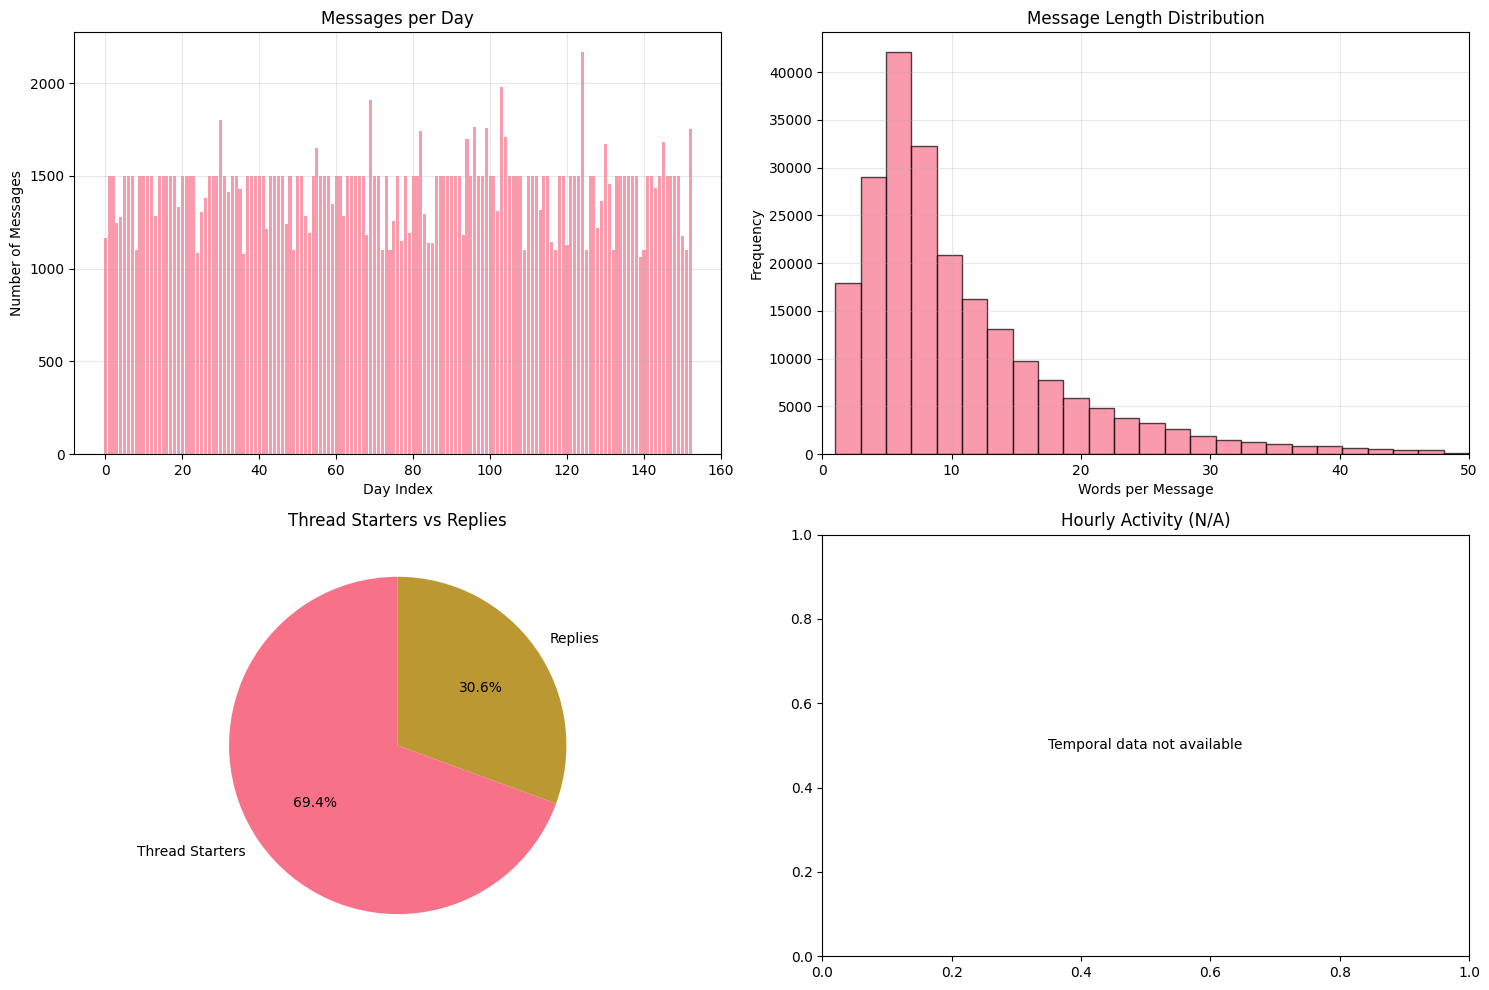

In [ ]:
message_stats = analyze_conversation_structure(df)

In [ ]:

def analyze_user_participation(df):
    """Analyze user participation patterns"""
    print("\nUser Participation Analysis:")
    print("-" * 30)

    # Extract usernames from IRC messages (format: <username> message)
    username_pattern = r'<([^>]+)>'
    df['username'] = df['text'].str.extract(username_pattern, expand=False)

    # Filter out system messages and bots
    user_messages = df[df['username'].notna()].copy()

    if len(user_messages) == 0:
        print("No user messages found with extractable usernames")
        return None

    user_counts = user_messages['username'].value_counts()
    print(f"Total messages with usernames: {len(user_messages)}")
    print(f"Unique users: {len(user_counts)}")
    print(f"Average messages per user: {user_counts.mean():.2f}")
    print(f"Median messages per user: {user_counts.median():.0f}")

    # Identify potential bots (users with very systematic naming)
    bot_patterns = ['bot', 'ubuntu', 'ubottu', 'ubot']
    potential_bots = user_counts[user_counts.index.str.contains('|'.join(bot_patterns), case=False, na=False)]

    print(f"\nPotential bots identified: {len(potential_bots)}")
    if len(potential_bots) > 0:
        print("Top bot accounts:")
        for bot, count in potential_bots.head(5).items():
            print(f"  {bot}: {count} messages")

    # Top human users (excluding likely bots)
    human_users = user_counts[~user_counts.index.str.contains('|'.join(bot_patterns), case=False, na=False)]
    print(f"\nTop 10 most active human users:")
    for user, count in human_users.head(10).items():
        print(f"  {user}: {count} messages")

    # Plot user activity distribution
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # User activity distribution (log scale)
    axes[0, 0].hist(user_counts.values, bins=50, alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('Number of Messages')
    axes[0, 0].set_ylabel('Number of Users')
    axes[0, 0].set_title('User Activity Distribution')
    axes[0, 0].set_yscale('log')
    axes[0, 0].grid(True, alpha=0.3)

    # Top 20 users
    top_users = user_counts.head(20)
    axes[0, 1].barh(range(len(top_users)), top_users.values)
    axes[0, 1].set_yticks(range(len(top_users)))
    axes[0, 1].set_yticklabels(top_users.index, fontsize=8)
    axes[0, 1].set_xlabel('Number of Messages')
    axes[0, 1].set_title('Top 20 Most Active Users')
    axes[0, 1].invert_yaxis()

    # Messages per day by user type
    user_messages['is_bot'] = user_messages['username'].str.contains('|'.join(bot_patterns), case=False, na=False)
    daily_user_activity = user_messages.groupby(['day_index', 'is_bot']).size().unstack(fill_value=0)

    if len(daily_user_activity.columns) > 1:
        axes[1, 0].plot(daily_user_activity.index, daily_user_activity[False], label='Human Users', marker='o')
        axes[1, 0].plot(daily_user_activity.index, daily_user_activity[True], label='Bots', marker='s')
        axes[1, 0].set_xlabel('Day Index')
        axes[1, 0].set_ylabel('Number of Messages')
        axes[1, 0].set_title('Daily Activity: Humans vs Bots')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    else:
        # If no clear bot separation, show total activity
        daily_activity = user_messages.groupby('day_index').size()
        axes[1, 0].plot(daily_activity.index, daily_activity.values, marker='o')
        axes[1, 0].set_xlabel('Day Index')
        axes[1, 0].set_ylabel('Number of Messages')
        axes[1, 0].set_title('Daily User Activity')
        axes[1, 0].grid(True, alpha=0.3)

    # User participation by hour
    if 'hour' in user_messages.columns:
        hourly_users = user_messages.groupby('hour')['username'].nunique()
        axes[1, 1].bar(hourly_users.index, hourly_users.values, alpha=0.7)
        axes[1, 1].set_xlabel('Hour of Day')
        axes[1, 1].set_ylabel('Unique Users')
        axes[1, 1].set_title('Unique Users Active by Hour')
        axes[1, 1].set_xticks(range(0, 24, 2))
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'Temporal data not available',
                       horizontalalignment='center', verticalalignment='center',
                       transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Hourly User Activity (N/A)')

    plt.tight_layout()
    plt.show()

    return {
        'user_counts': user_counts,
        'human_users': human_users,
        'potential_bots': potential_bots,
        'user_messages_df': user_messages
    }




User Participation Analysis:
------------------------------
Total messages with usernames: 196154
Unique users: 15741
Average messages per user: 12.46
Median messages per user: 4

Potential bots identified: 99
Top bot accounts:
  ubottu: 2376 messages
  ubotu: 1531 messages
  ubuntu: 269 messages
  FloodBot1: 142 messages
  shazbotmcnasty: 90 messages

Top 10 most active human users:
  ActionParsnip: 1786 messages
  Dr_Willis: 1570 messages
  Seveas: 1430 messages
  ikonia: 1309 messages
  bazhang: 925 messages
  Psil0Cybin: 892 messages
  cfhowlett: 723 messages
  daftykins: 703 messages
  jrib: 680 messages
  lotuspsychje: 672 messages


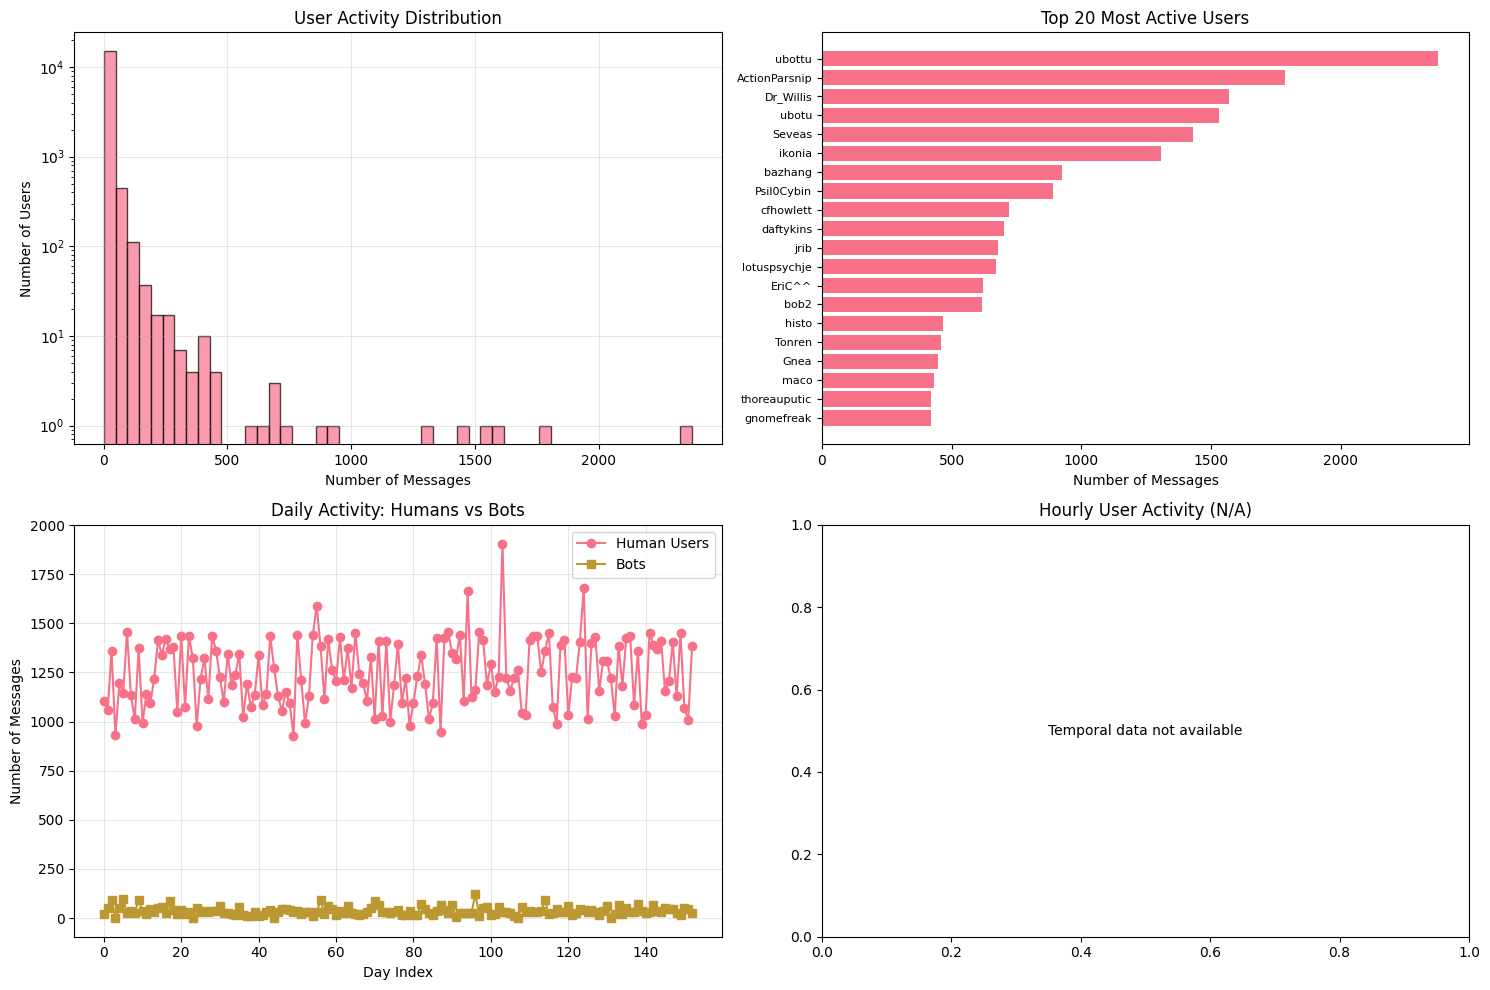

In [ ]:
user_stats = analyze_user_participation(df)

In [ ]:
def analyze_message_content(df):
    """Analyze message content characteristics"""
    print("\nMessage Content Analysis:")
    print("-" * 25)

    # Basic text statistics
    total_messages = len(df)
    print(f"Total messages analyzed: {total_messages}")

    # Message length analysis
    message_lengths = df['text'].str.len()
    word_counts = df['text'].str.split().str.len()

    print(f"Average characters per message: {message_lengths.mean():.1f}")
    print(f"Average words per message: {word_counts.mean():.1f}")

    # Extract just the message content (after username)
    username_pattern = r'<[^>]+>\s*(.*)'
    df['message_content'] = df['text'].str.extract(username_pattern, expand=False).fillna(df['text'])

    # Analyze message types
    url_messages = df['text'].str.contains(r'http[s]?://|www\.', case=False, na=False).sum()
    question_messages = df['text'].str.contains(r'\?', na=False).sum()
    command_messages = df['text'].str.contains(r'^[!/.]\w+', na=False).sum()

    print(f"\nMessage Types:")
    print(f"Messages with URLs: {url_messages} ({url_messages/total_messages*100:.1f}%)")
    print(f"Messages with questions: {question_messages} ({question_messages/total_messages*100:.1f}%)")
    print(f"Command messages: {command_messages} ({command_messages/total_messages*100:.1f}%)")

    # Word frequency analysis (sample first 5000 messages for performance)
    sample_messages = df['message_content'].dropna().head(5000)
    all_text = ' '.join(sample_messages)

    # Clean and tokenize
    words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())
    word_freq = Counter(words)

    # Remove very common stop words
    stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'can', 'must', 'shall', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his', 'her', 'its', 'our', 'their', 'this', 'that', 'these', 'those'}
    filtered_words = {word: count for word, count in word_freq.items() if word not in stop_words and len(word) > 2}

    print(f"\nTop 15 most common words (excluding stop words):")
    for word, count in sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)[:15]:
        print(f"  {word}: {count}")

    # Plot visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Message length distribution
    axes[0, 0].hist(word_counts.dropna(), bins=50, alpha=0.7, edgecolor='black', range=(0, 30))
    axes[0, 0].set_xlabel('Words per Message')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Message Length Distribution')
    axes[0, 0].grid(True, alpha=0.3)

    # Word frequency plot
    if filtered_words:
        top_words = sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)[:20]
        words, counts = zip(*top_words)
        axes[0, 1].barh(range(len(words)), counts)
        axes[0, 1].set_yticks(range(len(words)))
        axes[0, 1].set_yticklabels(words, fontsize=8)
        axes[0, 1].set_xlabel('Frequency')
        axes[0, 1].set_title('Top 20 Most Common Words')
        axes[0, 1].invert_yaxis()

    # Message types pie chart
    type_labels = ['URLs', 'Questions', 'Commands', 'Regular']
    type_counts = [url_messages, question_messages, command_messages,
                   total_messages - url_messages - question_messages - command_messages]

    # Remove zero counts
    filtered_labels = []
    filtered_counts = []
    for label, count in zip(type_labels, type_counts):
        if count > 0:
            filtered_labels.append(f'{label}\n({count})')
            filtered_counts.append(count)

    axes[1, 0].pie(filtered_counts, labels=filtered_labels, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Message Types Distribution')

    # Character length distribution
    axes[1, 1].hist(message_lengths, bins=50, alpha=0.7, edgecolor='black', range=(0, 200))
    axes[1, 1].set_xlabel('Characters per Message')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Character Length Distribution')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'word_freq': filtered_words,
        'message_lengths': message_lengths,
        'word_counts': word_counts,
        'message_types': {
            'urls': url_messages,
            'questions': question_messages,
            'commands': command_messages,
            'regular': total_messages - url_messages - question_messages - command_messages
        }
    }




Message Content Analysis:
-------------------------
Total messages analyzed: 220463
Average characters per message: 69.3
Average words per message: 10.7

Message Types:
Messages with URLs: 7088 (3.2%)
Messages with questions: 44114 (20.0%)
Command messages: 0 (0.0%)

Top 15 most common words (excluding stop words):
  ubuntu: 1046
  joined: 473
  not: 322
  what: 302
  how: 272
  get: 242
  com: 235
  install: 200
  now: 197
  from: 196
  just: 189
  there: 179
  net: 175
  help: 172
  use: 159


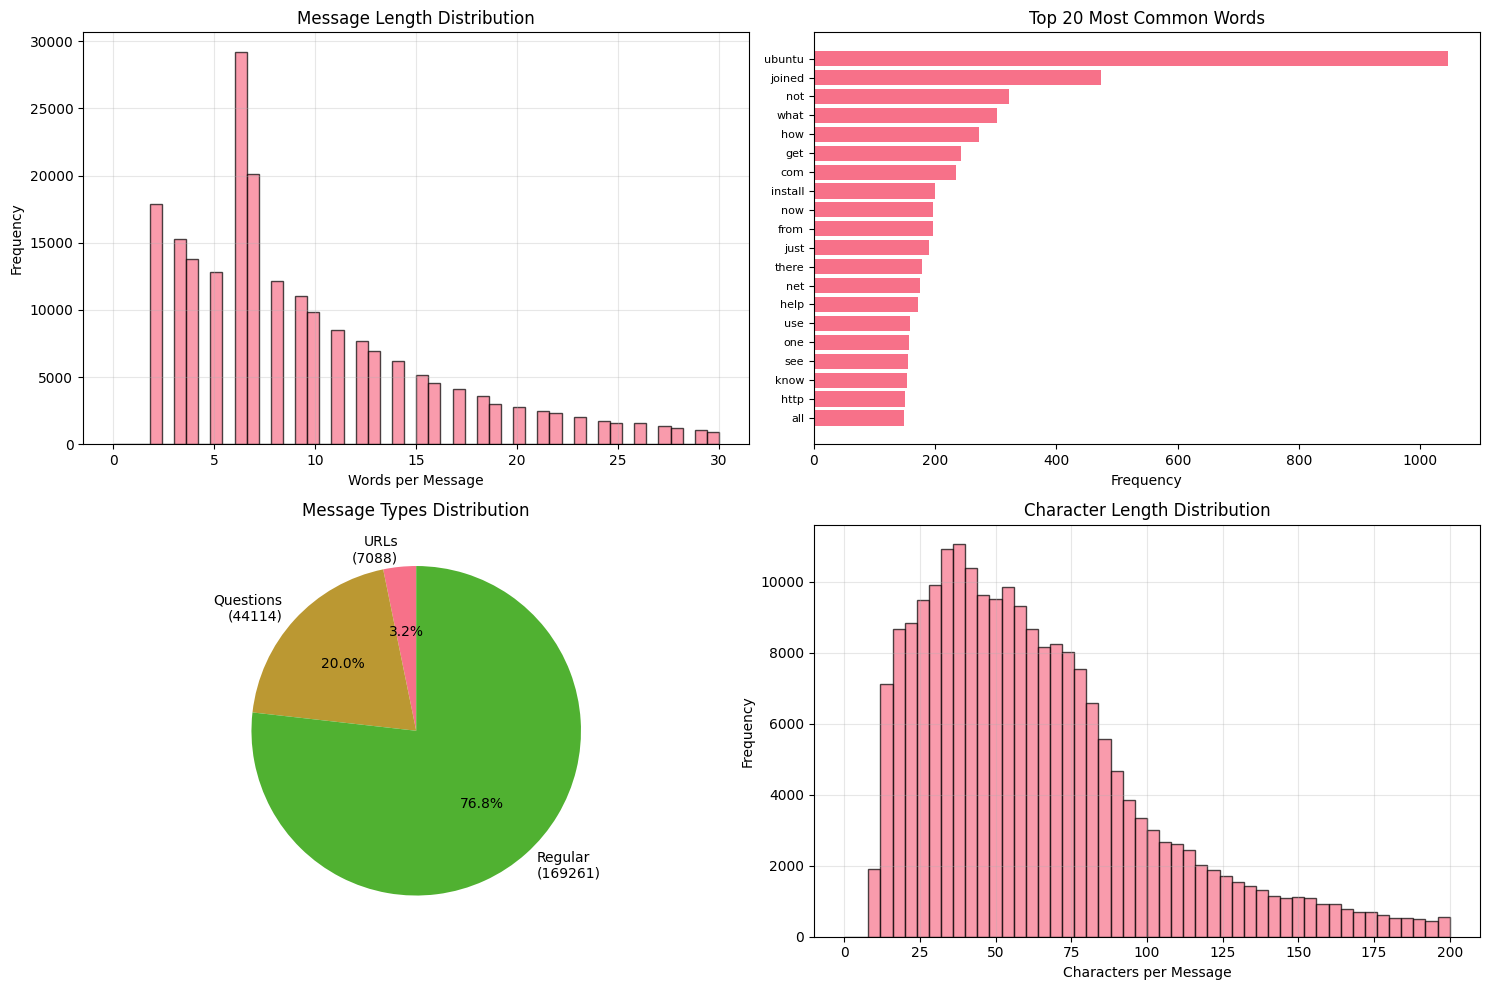

In [ ]:
content_stats = analyze_message_content(df)

In [ ]:
def analyze_annotations(df):
    """Analyze conversation threading and disentanglement annotations"""
    print("\nConversation Threading Analysis:")
    print("-" * 35)

    # Root vs reply detection
    messages_with_parents = df[df['parents'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    root_messages = df[df['parents'].apply(lambda x: isinstance(x, list) and len(x) == 0)]

    total_messages = len(df)
    print(f"Total messages: {total_messages}")
    print(f"Root messages (thread starters): {len(root_messages)} ({len(root_messages)/total_messages*100:.1f}%)")
    print(f"Reply messages: {len(messages_with_parents)} ({len(messages_with_parents)/total_messages*100:.1f}%)")

    if len(messages_with_parents) > 0:
        # Analyze reply patterns
        parent_counts = messages_with_parents['parents'].apply(len)
        print(f"Average parents per reply: {parent_counts.mean():.2f}")
        print(f"Max parents for a single message: {parent_counts.max()}")

        # Multi-parent replies
        multi_parent_messages = messages_with_parents[parent_counts > 1]
        print(f"Messages with multiple parents: {len(multi_parent_messages)} ({len(multi_parent_messages)/total_messages*100:.1f}%)")

        # Debug: parent-child examples
        print(f"\nExample parent-child relationships:")
        for _, msg in messages_with_parents.head(5).iterrows():
            print(f"  Message {msg['message_id']} -> Parents: {msg['parents']}")

        # Build conversation threads
        print(f"\nAnalyzing conversation threads...")
        thread_info = analyze_conversation_threads(df)

        if thread_info:
            print(f"Number of conversation threads: {thread_info['num_threads']}")
            print(f"Average thread length: {thread_info['avg_thread_length']:.2f}")
            print(f"Longest thread: {thread_info['max_thread_length']} messages")
            print(f"Average thread depth: {thread_info['avg_depth']:.2f}")
            print(f"Maximum thread depth: {thread_info['max_depth']}")

        # --- Visualization ---
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Parent count distribution
        axes[0, 0].hist(parent_counts, bins=range(1, parent_counts.max() + 2), alpha=0.7, edgecolor='black')
        axes[0, 0].set_xlabel('Number of Parents')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of Parents per Reply')
        axes[0, 0].grid(True, alpha=0.3)

        # Thread length distribution
        if thread_info and 'thread_lengths' in thread_info:
            axes[0, 1].hist(thread_info['thread_lengths'], bins=30, alpha=0.7, edgecolor='black')
            axes[0, 1].set_xlabel('Thread Length (messages)')
            axes[0, 1].set_ylabel('Frequency')
            axes[0, 1].set_title('Thread Length Distribution')
            axes[0, 1].grid(True, alpha=0.3)
        else:
            axes[0, 1].text(0.5, 0.5, 'Thread analysis not available',
                            ha='center', va='center', transform=axes[0, 1].transAxes)
            axes[0, 1].set_title('Thread Length Distribution (N/A)')

        # Root vs replies by hour (if timestamp extractable)
        if 'timestamp' in df.columns:
            try:
                df['hour'] = df['timestamp'].str.extract(r'_(\d{2})_\d{2}$').astype(int)
                hourly_roots = root_messages.groupby('hour').size()
                hourly_replies = messages_with_parents.groupby('hour').size()

                hours = range(24)
                root_counts = [hourly_roots.get(h, 0) for h in hours]
                reply_counts = [hourly_replies.get(h, 0) for h in hours]

                axes[1, 0].bar(hours, root_counts, alpha=0.7, label='Thread Starters', width=0.4)
                axes[1, 0].bar([h + 0.4 for h in hours], reply_counts, alpha=0.7, label='Replies', width=0.4)
                axes[1, 0].set_xlabel('Hour of Day')
                axes[1, 0].set_ylabel('Number of Messages')
                axes[1, 0].set_title('Thread Starters vs Replies by Hour')
                axes[1, 0].legend()
                axes[1, 0].set_xticks(range(0, 24, 2))
                axes[1, 0].grid(True, alpha=0.3)
            except Exception:
                axes[1, 0].text(0.5, 0.5, 'Temporal parsing failed',
                                ha='center', va='center', transform=axes[1, 0].transAxes)
                axes[1, 0].set_title('Threading by Hour (N/A)')
        else:
            axes[1, 0].text(0.5, 0.5, 'Temporal data not available',
                            ha='center', va='center', transform=axes[1, 0].transAxes)
            axes[1, 0].set_title('Threading by Hour (N/A)')

        # Threading patterns over days
        daily_roots = root_messages.groupby('day_index').size()
        daily_replies = messages_with_parents.groupby('day_index').size()
        daily_complex = multi_parent_messages.groupby('day_index').size() if len(multi_parent_messages) > 0 else pd.Series(dtype=int)

        axes[1, 1].plot(daily_roots.index, daily_roots.values, 'o-', label='Thread Starters', alpha=0.7)
        axes[1, 1].plot(daily_replies.index, daily_replies.values, 's-', label='Replies', alpha=0.7)
        if len(daily_complex) > 0:
            axes[1, 1].plot(daily_complex.index, daily_complex.values, '^-', label='Multi-parent', alpha=0.7)
        axes[1, 1].set_xlabel('Day Index')
        axes[1, 1].set_ylabel('Number of Messages')
        axes[1, 1].set_title('Threading Patterns Over Time')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return {
            'total_messages': total_messages,
            'root_messages': len(root_messages),
            'reply_messages': len(messages_with_parents),
            'multi_parent_messages': len(multi_parent_messages),
            'parent_counts': parent_counts,
            'thread_info': thread_info
        }
    else:
        print("No threaded conversations found in the dataset")
        return None


In [ ]:
def analyze_conversation_threads(df):
    """Analyze the structure of conversation threads"""
    try:
        print("Building thread relationships...")

        msg_map = {}
        children_map = defaultdict(list)

        for _, row in df.iterrows():
            msg_id = row['message_id']
            parents = row['parents'] if isinstance(row['parents'], list) else []

            msg_map[msg_id] = {
                'parents': parents,
                'text': row['text'],
                'timestamp': row['timestamp'],
                'day_index': row['day_index']
            }

            # Build reverse mapping, skip self-loops
            for parent_id in parents:
                if parent_id != msg_id:
                    children_map[parent_id].append(msg_id)

        print(f"Total messages: {len(msg_map)}")
        print(f"Messages with children: {len(children_map)}")

        # Find root messages
        root_messages = df[df['parents'].apply(lambda x: isinstance(x, list) and len(x) == 0)]['message_id'].tolist()
        print(f"Root messages found: {len(root_messages)}")

        # Debug sample mappings
        sample_with_children = list(children_map.items())[:5]
        if sample_with_children:
            print("Sample threading relationships:")
            for parent, children in sample_with_children:
                print(f"  {parent} -> {children}")

        threads, thread_lengths, thread_depths = [], [], []

        def get_thread_size_and_depth(msg_id):
            """Calculate thread size and depth using DFS (avoids cycles per thread)"""
            stack = [(msg_id, 1)]
            visited = set()
            max_depth, total_size = 0, 0

            while stack:
                current_id, current_depth = stack.pop()
                if current_id in visited or current_id not in msg_map:
                    continue

                visited.add(current_id)
                total_size += 1
                max_depth = max(max_depth, current_depth)

                for child_id in children_map.get(current_id, []):
                    if child_id not in visited:
                        stack.append((child_id, current_depth + 1))

            return total_size, max_depth

        # Process roots
        for root_id in root_messages[:100]:  # safety limit
            size, depth = get_thread_size_and_depth(root_id)
            if size > 0:
                threads.append({'root': root_id, 'size': size, 'depth': depth})
                thread_lengths.append(size)
                thread_depths.append(depth)

        if threads:
            # Top 10 largest
            interesting_threads = sorted(threads, key=lambda x: x['size'], reverse=True)[:10]
            print("Top 10 largest threads:")
            for i, thread in enumerate(interesting_threads):
                print(f"  {i+1}. Root: {thread['root']}, Size: {thread['size']}, Depth: {thread['depth']}")

            print(f"\nThread size distribution:")
            size_counts = Counter(thread_lengths)
            for size in sorted(size_counts.keys())[:10]:
                print(f"  Size {size}: {size_counts[size]} threads")

            print(f"\nThread depth distribution:")
            depth_counts = Counter(thread_depths)
            for depth in sorted(depth_counts.keys())[:10]:
                print(f"  Depth {depth}: {depth_counts[depth]} threads")

            return {
                'num_threads': len(threads),
                'avg_thread_length': np.mean(thread_lengths),
                'max_thread_length': max(thread_lengths),
                'avg_depth': np.mean(thread_depths),
                'max_depth': max(thread_depths),
                'thread_lengths': thread_lengths,
                'thread_depths': thread_depths,
                'threads': threads,
                'children_map_size': len(children_map)
            }
        else:
            print("No threads found!")
            return None

    except Exception as e:
        print(f"Error analyzing threads: {e}")
        import traceback
        traceback.print_exc()
        return None



Conversation Threading Analysis:
-----------------------------------
Total messages: 220463
Root messages (thread starters): 153000 (69.4%)
Reply messages: 67463 (30.6%)
Average parents per reply: 1.03
Max parents for a single message: 7
Messages with multiple parents: 1753 (0.8%)

Example parent-child relationships:
  Message 2013-05-05_01000 -> Parents: ['2013-05-05_00999']
  Message 2013-05-05_01001 -> Parents: ['2013-05-05_01001']
  Message 2013-05-05_01002 -> Parents: ['2013-05-05_01002']
  Message 2013-05-05_01003 -> Parents: ['2013-05-05_01002']
  Message 2013-05-05_01004 -> Parents: ['2013-05-05_01003']

Analyzing conversation threads...
Building thread relationships...
Total messages: 220463
Messages with children: 38950
Root messages found: 153000
Sample threading relationships:
  2013-05-05_00999 -> ['2013-05-05_01000']
  2013-05-05_01002 -> ['2013-05-05_01003']
  2013-05-05_01003 -> ['2013-05-05_01004']
  2013-05-05_01006 -> ['2013-05-05_01008']
  2013-05-05_01012 -> ['201

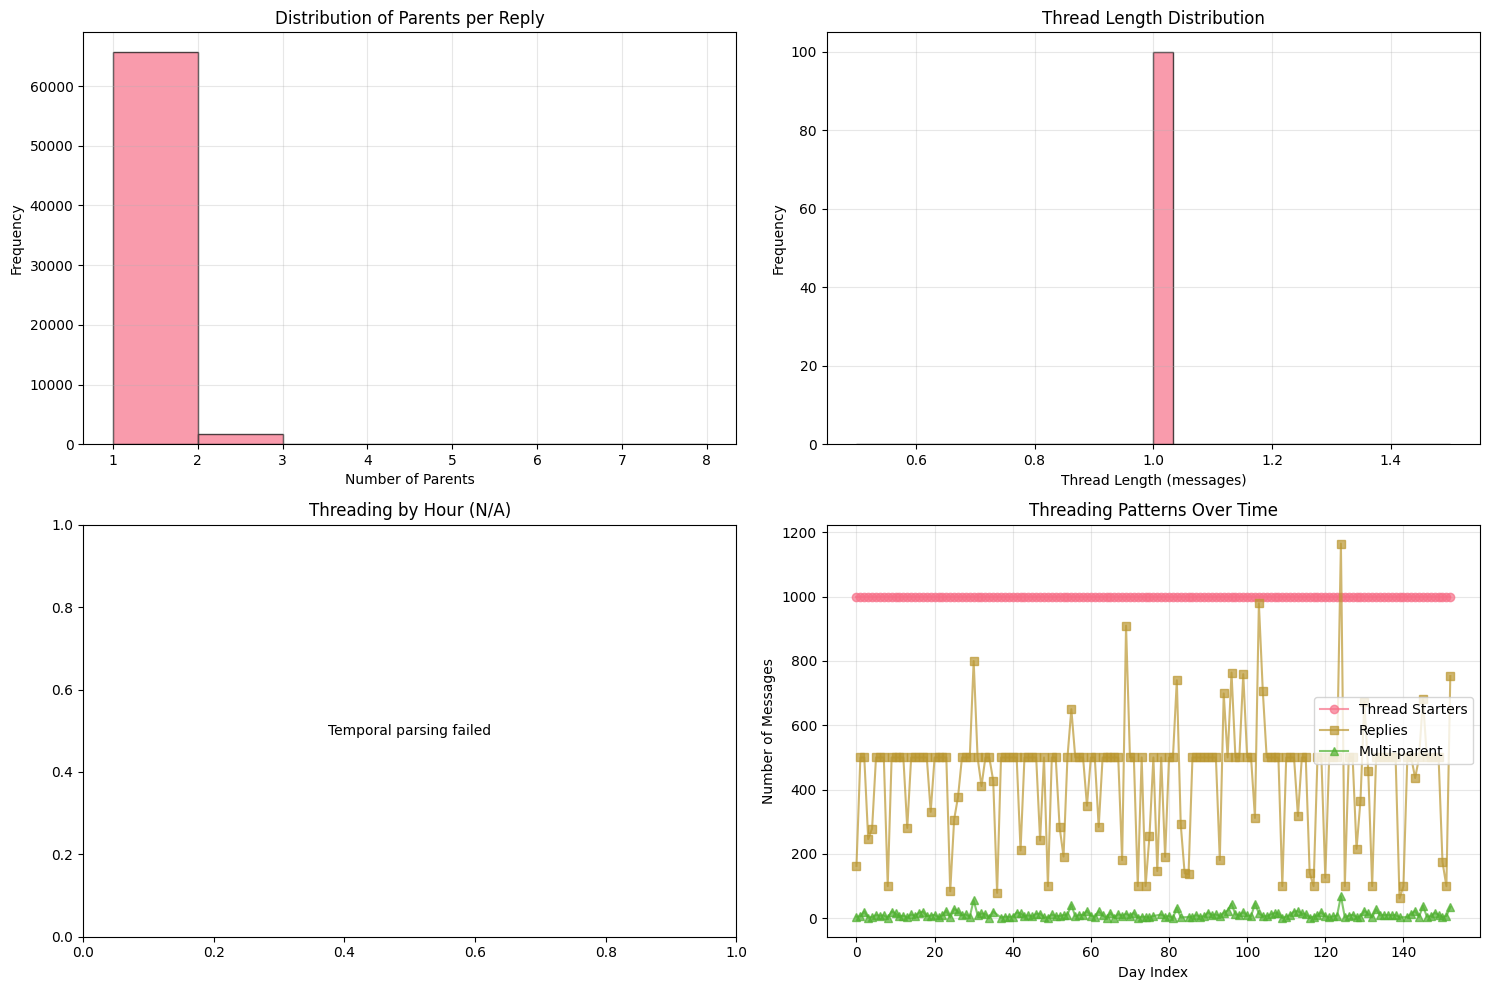

In [ ]:
annotation_stats = analyze_annotations(df)

In [ ]:
def analyze_disentanglement_task(df):
    """Analyze the dataset from the perspective of conversation disentanglement"""
    print("\n" + "="*60)
    print("DISENTANGLEMENT TASK ANALYSIS")
    print("="*60)

    # This is the core task: separating interleaved conversations
    total_messages = len(df)

    # Messages that start new threads vs continue existing ones
    thread_starters = df[df['parents'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)]
    thread_continuations = df[df['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]

    print(f"Dataset Statistics for Disentanglement:")
    print(f"- Total messages: {total_messages:,}")
    print(f"- Thread starters: {len(thread_starters):,} ({len(thread_starters)/total_messages*100:.1f}%)")
    print(f"- Thread continuations: {len(thread_continuations):,} ({len(thread_continuations)/total_messages*100:.1f}%)")

    # Complexity metrics for disentanglement
    if len(thread_continuations) > 0:
        # Messages with multiple parents (most challenging for disentanglement)
        multi_parent = thread_continuations[thread_continuations['parents'].apply(len) > 1]
        print(f"- Multi-parent messages: {len(multi_parent):,} ({len(multi_parent)/total_messages*100:.2f}%)")

        # Average time gaps between messages and their parents
        print(f"\nTemporal Complexity:")
        analyze_temporal_patterns(df)

        # Content-based disentanglement challenges
        print(f"\nContent-based Challenges:")
        analyze_content_challenges(df)

    return {
        'total_messages': total_messages,
        'thread_starters': len(thread_starters),
        'thread_continuations': len(thread_continuations),
        'multi_parent_messages': len(multi_parent) if len(thread_continuations) > 0 else 0
    }



In [ ]:

def analyze_temporal_patterns(df):
    """Analyze temporal patterns relevant to disentanglement"""
    try:
        # Convert timestamps to datetime for analysis
        df_temp = df.copy()
        df_temp['datetime'] = pd.to_datetime(df_temp['timestamp'], format='%Y-%m-%d_%H_%M', errors='coerce')

        # For messages with parents, calculate time gaps
        messages_with_parents = df_temp[df_temp['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)]

        if len(messages_with_parents) > 0:
            time_gaps = []

            for _, msg in messages_with_parents.head(100).iterrows():  # Sample for performance
                msg_time = msg['datetime']
                if pd.isna(msg_time):
                    continue

                for parent_id in msg['parents']:
                    parent_msg = df_temp[df_temp['message_id'] == parent_id]
                    if len(parent_msg) > 0:
                        parent_time = parent_msg.iloc[0]['datetime']
                        if not pd.isna(parent_time):
                            gap = (msg_time - parent_time).total_seconds()
                            if gap > 0:  # Only positive gaps make sense
                                time_gaps.append(gap)

            if time_gaps:
                print(f"- Average response time: {np.mean(time_gaps)/60:.1f} minutes")
                print(f"- Median response time: {np.median(time_gaps)/60:.1f} minutes")
                print(f"- Response time range: {min(time_gaps)/60:.1f} - {max(time_gaps)/3600:.1f} minutes-hours")

    except Exception as e:
        print(f"- Could not analyze temporal patterns: {e}")



In [ ]:

def analyze_content_challenges(df):
    """Analyze content-based challenges for disentanglement"""
    try:
        # Extract usernames
        df_temp = df.copy()
        df_temp['username'] = df_temp['text'].str.extract(r'<([^>]+)>', expand=False)

        # Messages without clear usernames (system messages, etc.)
        unclear_messages = df_temp[df_temp['username'].isna()]
        print(f"- Messages without clear usernames: {len(unclear_messages)} ({len(unclear_messages)/len(df)*100:.1f}%)")

        # Very short messages (harder to classify)
        short_messages = df_temp[df_temp['text'].str.len() < 20]
        print(f"- Very short messages (<20 chars): {len(short_messages)} ({len(short_messages)/len(df)*100:.1f}%)")

        # Messages with URLs (might be easier to track)
        url_messages = df_temp[df_temp['text'].str.contains(r'http[s]?://|www\.', case=False, na=False)]
        print(f"- Messages with URLs: {len(url_messages)} ({len(url_messages)/len(df)*100:.1f}%)")

    except Exception as e:
        print(f"- Could not analyze content challenges: {e}")



In [ ]:
 # Disentanglement-specific analysis
disentanglement_stats = analyze_disentanglement_task(df)


DISENTANGLEMENT TASK ANALYSIS
Dataset Statistics for Disentanglement:
- Total messages: 220,463
- Thread starters: 153,000 (69.4%)
- Thread continuations: 67,463 (30.6%)
- Multi-parent messages: 1,753 (0.80%)

Temporal Complexity:
- Average response time: 1.2 minutes
- Median response time: 1.0 minutes
- Response time range: 1.0 - 0.1 minutes-hours

Content-based Challenges:
- Messages without clear usernames: 24309 (11.0%)
- Very short messages (<20 chars): 17709 (8.0%)
- Messages with URLs: 7088 (3.2%)


In [ ]:

# ============================================================================
# 4. VISUALIZATION FUNCTIONS
# ============================================================================

def create_conversation_heatmap(df, max_days=10):
    """Create visualizations showing conversation threading patterns"""
    if len(df) == 0:
        print("No data available for heatmap")
        return

    print(f"Creating threading visualizations for {min(max_days, df['day_index'].nunique())} days...")

    # Prepare data for analysis
    daily_data = []
    for day_idx in sorted(df['day_index'].unique())[:max_days]:
        day_df = df[df['day_index'] == day_idx]

        total_msgs = len(day_df)
        root_msgs = len(day_df[day_df['parents'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)])
        reply_msgs = len(day_df[day_df['parents'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)])

        # Extract unique users for this day
        day_df_copy = day_df.copy()
        day_df_copy['username'] = day_df_copy['text'].str.extract(r'<([^>]+)>', expand=False)
        unique_users = day_df_copy['username'].nunique()

        daily_data.append({
            'day': day_idx,
            'total_messages': total_msgs,
            'root_messages': root_msgs,
            'reply_messages': reply_msgs,
            'unique_users': unique_users,
            'threading_ratio': reply_msgs / total_msgs if total_msgs > 0 else 0,
            'msgs_per_user': total_msgs / unique_users if unique_users > 0 else 0
        })

    if not daily_data:
        print("No daily data to visualize")
        return

    analysis_df = pd.DataFrame(daily_data)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Daily message volume heatmap
    days = analysis_df['day'].values
    metrics = ['total_messages', 'root_messages', 'reply_messages']
    heatmap_data = analysis_df[metrics].T

    im1 = axes[0, 0].imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
    axes[0, 0].set_xticks(range(len(days)))
    axes[0, 0].set_xticklabels([f'Day {d}' for d in days], rotation=45)
    axes[0, 0].set_yticks(range(len(metrics)))
    axes[0, 0].set_yticklabels(['Total', 'Roots', 'Replies'])
    axes[0, 0].set_title('Message Volume Heatmap')

    # Add text annotations
    for i in range(len(metrics)):
        for j in range(len(days)):
            text = axes[0, 0].text(j, i, int(heatmap_data.iloc[i, j]),
                                 ha="center", va="center", color="black", fontsize=8)

    plt.colorbar(im1, ax=axes[0, 0])

    # 2. Threading ratio over time
    axes[0, 1].plot(analysis_df['day'], analysis_df['threading_ratio'], 'bo-', alpha=0.7)
    axes[0, 1].set_xlabel('Day Index')
    axes[0, 1].set_ylabel('Reply Ratio')
    axes[0, 1].set_title('Threading Activity Over Time')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(0, 1)

    # 3. User engagement
    axes[0, 2].scatter(analysis_df['unique_users'], analysis_df['total_messages'],
                      c=analysis_df['threading_ratio'], cmap='viridis', alpha=0.7, s=100)
    axes[0, 2].set_xlabel('Unique Users')
    axes[0, 2].set_ylabel('Total Messages')
    axes[0, 2].set_title('User Engagement vs Threading')
    cbar = plt.colorbar(axes[0, 2].collections[0], ax=axes[0, 2])
    cbar.set_label('Threading Ratio')

    # 4. Messages per user distribution
    axes[1, 0].bar(range(len(analysis_df)), analysis_df['msgs_per_user'], alpha=0.7)
    axes[1, 0].set_xlabel('Day Index')
    axes[1, 0].set_ylabel('Messages per User')
    axes[1, 0].set_title('Daily Activity Intensity')
    axes[1, 0].set_xticks(range(len(analysis_df)))
    axes[1, 0].set_xticklabels([f'D{d}' for d in analysis_df['day']], rotation=45)

    # 5. Stacked bar chart of message types
    width = 0.6
    axes[1, 1].bar(range(len(analysis_df)), analysis_df['root_messages'],
                   width, label='Thread Starters', alpha=0.8)
    axes[1, 1].bar(range(len(analysis_df)), analysis_df['reply_messages'],
                   width, bottom=analysis_df['root_messages'], label='Replies', alpha=0.8)
    axes[1, 1].set_xlabel('Day Index')
    axes[1, 1].set_ylabel('Number of Messages')
    axes[1, 1].set_title('Message Types by Day')
    axes[1, 1].legend()
    axes[1, 1].set_xticks(range(len(analysis_df)))
    axes[1, 1].set_xticklabels([f'D{d}' for d in analysis_df['day']], rotation=45)

    # 6. Correlation matrix
    corr_metrics = ['total_messages', 'unique_users', 'threading_ratio', 'msgs_per_user']
    correlation_matrix = analysis_df[corr_metrics].corr()

    im6 = axes[1, 2].imshow(correlation_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    axes[1, 2].set_xticks(range(len(corr_metrics)))
    axes[1, 2].set_yticks(range(len(corr_metrics)))
    axes[1, 2].set_xticklabels([m.replace('_', '\n') for m in corr_metrics], rotation=45, ha='right')
    axes[1, 2].set_yticklabels([m.replace('_', '\n') for m in corr_metrics])
    axes[1, 2].set_title('Feature Correlations')

    # Add correlation values
    for i in range(len(corr_metrics)):
        for j in range(len(corr_metrics)):
            text = axes[1, 2].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                                 ha="center", va="center",
                                 color="white" if abs(correlation_matrix.iloc[i, j]) > 0.5 else "black",
                                 fontsize=10)

    plt.colorbar(im6, ax=axes[1, 2])

    plt.tight_layout()
    plt.show()

    return analysis_df


Creating threading visualizations for 10 days...


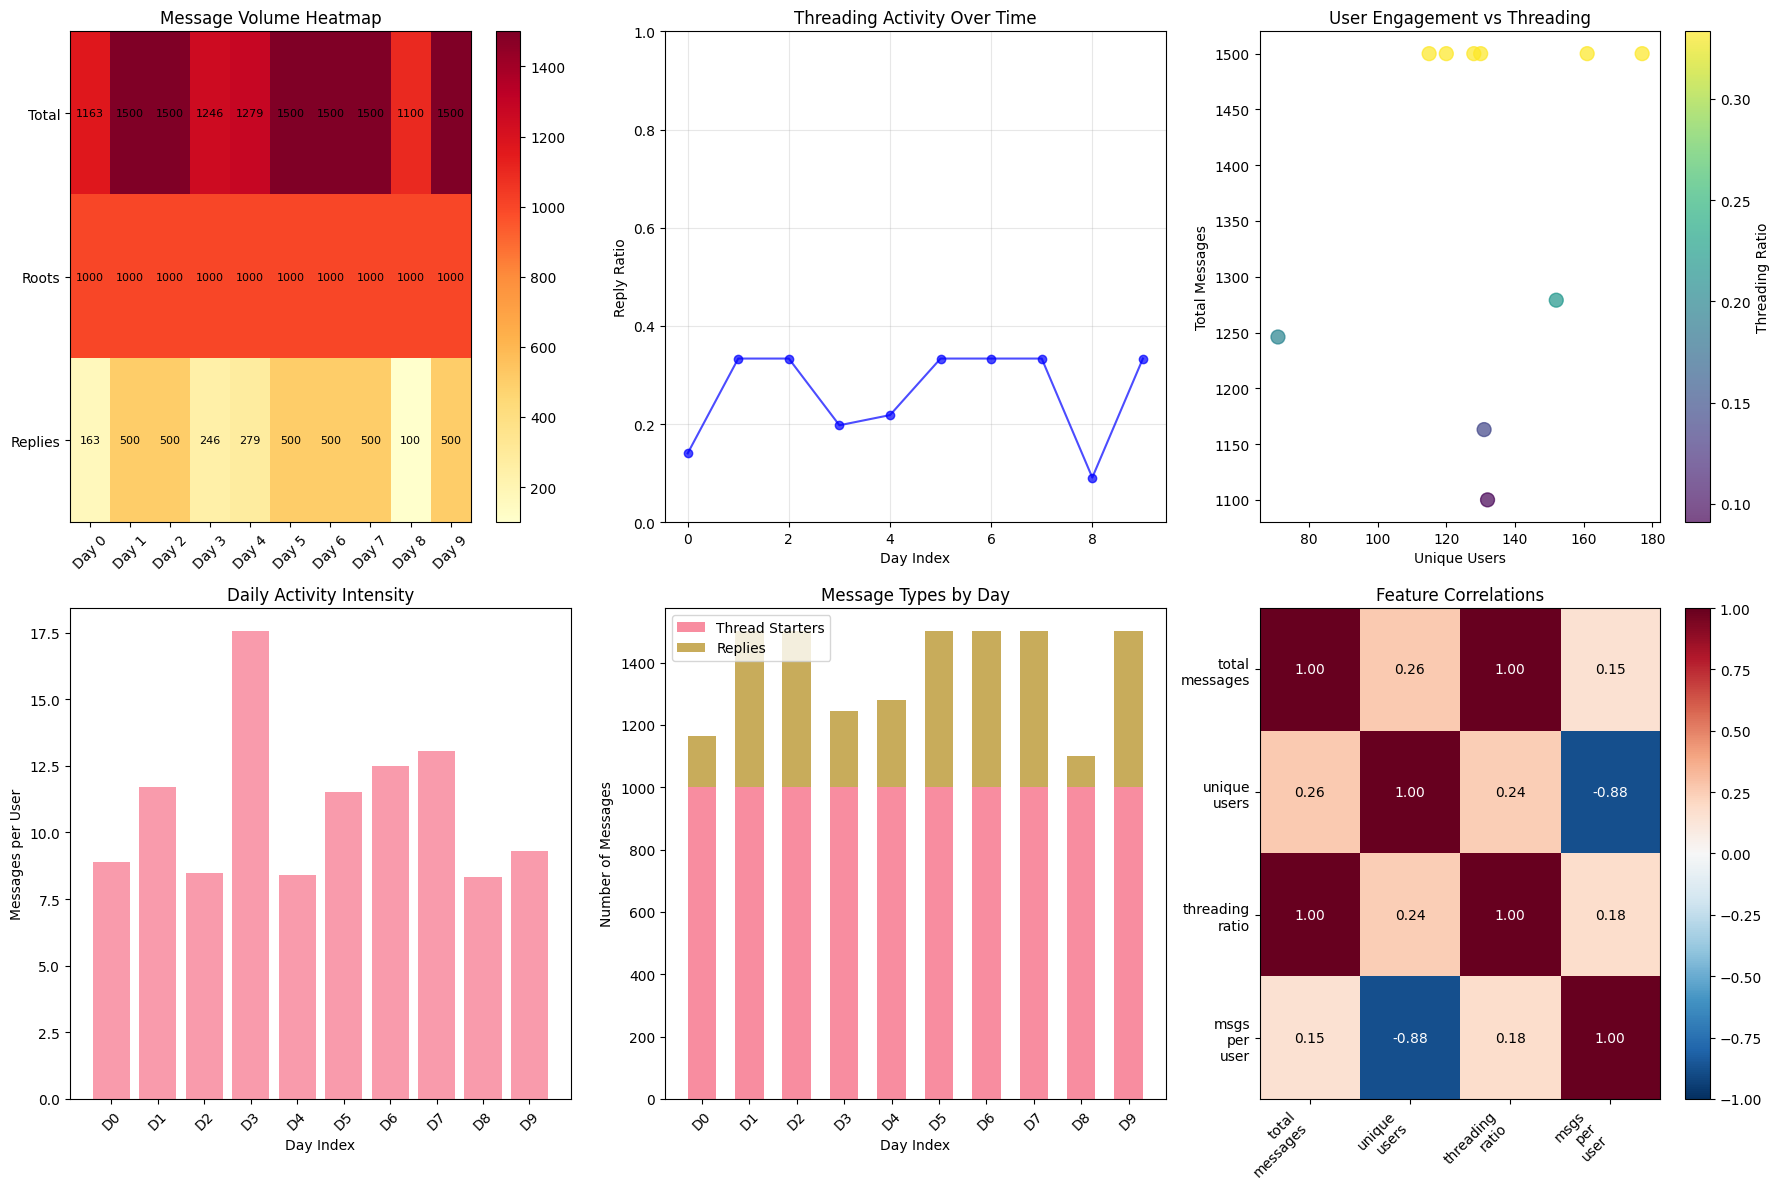

In [ ]:
 # Create visualizations
heatmap_data = create_conversation_heatmap(df)

In [ ]:

# ============================================================================
# 6. ADDITIONAL UTILITY FUNCTIONS
# ============================================================================

def export_sample_data(df, filename='irc_sample.csv', n_samples=100):
    """Export a sample of the data for further analysis"""
    if df is not None:
        sample_df = df.head(n_samples).copy()

        # Convert list columns to string for CSV export
        for col in sample_df.columns:
            if sample_df[col].dtype == 'object':
                sample_df[col] = sample_df[col].astype(str)

        sample_df.to_csv(filename, index=False)
        print(f"Exported {len(sample_df)} samples to {filename}")

def search_conversations(df, keyword, max_results=5):
    """Search for messages containing a specific keyword"""
    if 'text' not in df.columns:
        print("No text column found")
        return

    matching_msgs = df[df['text'].str.contains(keyword, case=False, na=False)]

    print(f"Found {len(matching_msgs)} messages containing '{keyword}'")

    if len(matching_msgs) == 0:
        return

    # Group by day and show context
    for day_idx in matching_msgs['day_index'].unique()[:max_results]:
        day_matches = matching_msgs[matching_msgs['day_index'] == day_idx]
        print(f"\n--- Day {day_idx} ({len(day_matches)} matches) ---")

        for _, msg in day_matches.head(3).iterrows():  # Show first 3 matches per day
            print(f"[{msg['timestamp']}] {msg['text']}")

            # Show parent context if available
            if isinstance(msg['parents'], list) and len(msg['parents']) > 0:
                print(f"  ^ Replying to: {msg['parents']}")

        if len(day_matches) > 3:
            print(f"  ... and {len(day_matches) - 3} more matches this day")

def analyze_thread_example(df, message_id):
    """Analyze a specific thread starting from a given message"""
    if message_id not in df['message_id'].values:
        print(f"Message ID '{message_id}' not found in dataset")
        return

    # Find the message and its thread
    msg = df[df['message_id'] == message_id].iloc[0]
    print(f"Analyzing thread for message: {message_id}")
    print(f"Original message: {msg['text']}")
    print(f"Parents: {msg['parents']}")

    # Find all messages in the same day for context
    day_df = df[df['day_index'] == msg['day_index']]

    # Find children (messages that reference this one)
    children = day_df[day_df['parents'].apply(
        lambda x: message_id in x if isinstance(x, list) else False
    )]

    if len(children) > 0:
        print(f"\nFound {len(children)} direct replies:")
        for _, child in children.iterrows():
            print(f"  -> [{child['message_id']}] {child['text']}")
    else:
        print("\nNo direct replies found")

    # If this message has parents, show them
    if isinstance(msg['parents'], list) and len(msg['parents']) > 0:
        print(f"\nParent messages:")
        for parent_id in msg['parents']:
            parent_msg = day_df[day_df['message_id'] == parent_id]
            if len(parent_msg) > 0:
                print(f"  <- [{parent_id}] {parent_msg.iloc[0]['text']}")

    return {
        'original_message': msg,
        'children': children,
        'day_context': day_df
    }

# # Run the main analysis
# if __name__ == "__main__":
#     df, examples = main()

In [ ]:
export_sample_data(df, 'ircDF.csv')

Exported 100 samples to ircDF.csv


In [ ]:

# def main():
#     """Main execution function"""
#     print("Starting IRC Dataset Analysis...")
#     print("=" * 50)

#     # Load the training dataset
#     train_dataset = load_irc_dataset('train')

#     if train_dataset is None:
#         print("Failed to load dataset. Please check your installation.")
#         return

#     # Get dataset info
#     dataset_info = get_dataset_info()

#     # Explore structure
#     examples = explore_dataset_structure(train_dataset, num_examples=3)

#     # Convert to DataFrame for easier analysis
#     df = convert_to_dataframe(train_dataset, max_examples=500)

#     if df is not None and not df.empty:
#         print(f"\nDataFrame shape: {df.shape}")
#         print(f"Columns: {list(df.columns)}")

#         # Run analyses
#         message_stats = analyze_conversation_structure(df)
#         user_stats = analyze_user_participation(df)
#         content_stats = analyze_message_content(df)
#         annotation_stats = analyze_annotations(df)

#         # Disentanglement-specific analysis
#         disentanglement_stats = analyze_disentanglement_task(df)

#         # Create visualizations
#         heatmap_data = create_conversation_heatmap(df)

#         print("\nAnalysis complete!")
#         print("=" * 50)

#         print("\nYou can now use the following variables:")
#         print("- df: DataFrame with IRC message data")
#         print("- examples: Raw examples from the dataset")
#         print("\nTry additional analyses like:")
#         print("- search_conversations(df, 'your_keyword')")
#         print("- analyze_thread_example(df, 'message_id')")
#         print("- export_sample_data(df, 'filename.csv')")
#         print("\nExample message IDs to explore:")
#         if len(df) > 0:
#             sample_ids = df['message_id'].head(5).tolist()
#             for msg_id in sample_ids:
#                 print(f"  - {msg_id}")

#         return df, examples
#     else:
#         print("Failed to create DataFrame from dataset")
#         return None, examples